In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Cleaning

 - 1.1 Load Data
 - 1.2 Standardise Missing Values
 - 1.3 Clean ID/Grouping columns
 - 1.4 Restrict to project age range

In [2]:
# ============================================================
# 1. DATA CLEANING
# ============================================================

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

# ----------------------------
# 1.1 Load HBSC raw dataset
# ----------------------------
DATA_PATH = "HBSC_data/HBSC2018OAed1.1.csv"

df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    engine="python"
)

df_clean = df_raw.copy()

print("Raw dataset shape:", df_clean.shape)
display(df_clean.head())

# ----------------------------
# 1.2 Standardise common missing values
# ----------------------------
missing_tokens = ["", " ", "  ", ".", "..", "...", "NA", "N/A", "na", "n/a"]

df_clean = df_clean.replace(missing_tokens, np.nan)

print("Common missing-value placeholders standardised.")

# ----------------------------
# 1.3 Clean key ID / grouping columns
# ----------------------------
# These are structural variables used for filtering or grouping later.
id_vars = ["age", "sex", "countryno"]

# Inspect age column, notice that intermediate ages like 15,6 neeed to be replaced with 15.6
print("Sorted unique values in age column:", sorted(df_clean["age"].dropna().unique()))

if "age" in df_clean.columns:
    df_clean["age"] = (
        df_clean["age"]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")

# Convert other ID/grouping columns to numeric
for col in ["sex", "countryno"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Key ID / grouping columns cleaned.")

# ----------------------------
# 1.4 Restrict to project age range
# ----------------------------
# Project scope: students aged 13 to 16.5
if "age" in df_clean.columns:
    df_clean = df_clean[(df_clean["age"] >= 13) & (df_clean["age"] <= 16.5)].copy()

print("Dataset shape after age filtering (13 to 16.5):", df_clean.shape)

Raw dataset shape: (244097, 120)


,HBSC,seqno_int,cluster,countryno,region,id1,id2,id3,id4,weight,adm,month,year,age,agecat,sex,grade,monthbirth,yearbirth,fasfamcar,fasbedroom,fascomputers,fasbathroom,fasdishwash,fasholidays,health,lifesat,headache,stomachache,backache,feellow,irritable,nervous,sleepdificulty,dizzy,thinkbody,physact60,breakfastwd,breakfastwe,fruits_2,vegetables_2,sweets_2,softdrinks_2,fmeal,toothbr,timeexe,smokltm,smok30d_2,alcltm,alc30d_2,drunkltm,drunk30d,cannabisltm_2,cannabis30d_2,bodyweight,bodyheight,likeschool,schoolpressure,studtogether,studhelpful,studaccept,teacheraccept,teachercare,teachertrust,bulliedothers,beenbullied,cbulliedothers,cbeenbullied,fight12m,injured12m,friendhelp,friendcounton,friendshare,friendtalk,emconlfreq1,emconlfreq2,emconlfreq3,emconlfreq4,emconlpref1,emconlpref2,emconlpref3,emcsocmed1,emcsocmed2,emcsocmed3,emcsocmed4,emcsocmed5,emcsocmed6,emcsocmed7,emcsocmed8,emcsocmed9,hadsex,agesex,contraceptcondom,contraceptpill,countryborn,countrybornmo,countrybornfa,motherhome1,fatherhome1,stepmohome1,stepfahome1,fosterhome1,elsehome1_2,employfa,employmo,employnotfa,employnotmo,talkfather,talkstepfa,talkmother,talkstepmo,famhelp,famsup,famtalk,famdec,MBMI,IRFAS,IRRELFAS_LMH,IOTF4,oweight_who
0,2018,100001,100231,8000,AL,10,58,231,321,1,1,5,2017,,,1,1,,,2,2,3,2,2,1,1,7,5,4,5,3,1,1,5,5,3,3,4,3,4,3,1,7,1,1,3,,2,,1,,2,,,41,151,1,1,2,1,1,1,1,1,2,1,5,3,2,2,7,6,7,5,4,5,5,5,2,1,1,2,1,1,2,2,2,1,1,1,,,,,AL,AL,AL,1,1,2,2,2,2,1,1,,,1,5,2,5,7,6,7,5,"17,981667470725",6,2,,
1,2018,100002,100238,8000,AL,10,60,238,611,1,1,5,2017,,,1,1,,,,,,,,,1,7,5,5,5,3,4,3,2,5,3,4,6,3,4,6,2,1,3,2,2,1,1,2,2,1,1,,,52,171,2,3,2,2,1,1,1,1,5,2,5,2,2,1,5,6,5,7,4,4,3,5,5,5,5,1,1,1,1,1,2,1,2,1,,,,,AL,AL,AL,1,1,2,2,2,2,1,1,,,2,5,1,5,7,7,7,7,"17,7832495468691",,,,
2,2018,100004,100066,8000,AL,3,16,66,1225,1,1,5,2017,,,1,1,,,2,,2,2,2,1,1,10,5,3,5,5,5,4,4,5,5,7,6,,5,2,4,3,1,2,2,1,1,1,1,1,1,,,59,156,2,3,1,1,1,1,1,1,1,1,1,2,1,1,7,1,7,1,1,6,6,6,5,5,1,2,2,2,1,2,2,1,2,2,,,,,AL,AL,AL,1,1,2,2,2,2,1,2,,1,1,5,1,5,7,7,1,7,"24,2439184746877",,,,
3,2018,100005,100047,8000,AL,3,14,47,1371,1,1,5,2017,,,1,1,,,,,,,,,,,5,5,4,5,5,5,5,4,3,3,6,3,7,7,4,2,1,1,2,1,1,1,1,1,1,,,38,159,1,1,1,1,1,1,1,1,1,2,2,1,1,1,7,7,7,7,4,1,2,3,1,1,1,1,1,1,2,1,2,1,1,1,,,,,AL,AL,AL,1,1,2,2,2,2,1,1,,,1,5,1,5,7,7,7,7,"15,0310509869072",,,,
4,2018,100007,100132,8000,AL,5,30,132,1604,1,1,5,2017,,,1,1,,,,,,,,,2,6,2,5,1,1,1,4,2,5,2,3,6,3,3,7,2,2,2,2,6,1,1,1,1,1,1,,,45,170,1,2,1,3,3,1,1,1,1,1,1,1,1,1,7,3,5,6,3,1,1,6,1,1,3,1,1,1,1,2,2,1,1,2,,,,,AL,AL,AL,1,1,2,2,2,1,1,1,,,4,5,2,5,2,1,1,1,"15,5709342560554",,,,


Common missing-value placeholders standardised.
Sorted unique values in age column: ['10', '10,5', '10,5833333333333', '10,5833333333335', '10,6666666666665', '10,6666666666667', '10,75', '10,8333333333333', '10,8333333333335', '10,9166666666665', '10,9166666666667', '11', '11,0833333333333', '11,0833333333335', '11,1666666666665', '11,1666666666667', '11,25', '11,3333333333333', '11,3333333333335', '11,4166666666665', '11,4166666666667', '11,5', '11,5833333333333', '11,5833333333335', '11,6666666666665', '11,6666666666667', '11,75', '11,8333333333333', '11,8333333333335', '11,9166666666665', '11,9166666666667', '12', '12,0833333333333', '12,0833333333335', '12,1666666666665', '12,1666666666667', '12,25', '12,3333333333333', '12,3333333333335', '12,4166666666665', '12,4166666666667', '12,5', '12,5833333333333', '12,5833333333335', '12,6666666666665', '12,6666666666667', '12,75', '12,8333333333333', '12,8333333333335', '12,9166666666665', '12,9166666666667', '13', '13,0833333333333', '1

# 2. Global Variable mapping

Create a single source of truth for:
variable labels
question stems
scales

 - 2.1 Item labels from HBSC codebook variable titles
 - 2.2 Full question stem function
 - 2.3 Build global mapping dataframe
 - 2.4 Fast lookup dictionaries
 - 2.5 Helper functions for notebook-wide use
 - 2.6 Quick verification

In [3]:
# ============================================================
# 2. GLOBAL VARIABLE MAPPING (DATA DICTIONARY)
# ============================================================

# All column names present in the cleaned dataset
cols = df_clean.columns.tolist()

# ----------------------------
# 2.1 Item labels from HBSC codebook variable titles
# ----------------------------
labels = {
    'HBSC':'HBSC round',
    'seqno_int':'Identify each row in cross national files',
    'cluster':'Identify each class or cluster in cross national files',
    'countryno':'Country/WHO region',
    'region':'HBSC region',
    'id1':'Region/municipality',
    'id2':'School',
    'id3':'Class',
    'id4':'Pupil no.',
    'weight':'Weight of dataset',
    'adm':'Mode of quest. adm.',
    'month':'Month of data collection',
    'year':'Year of data collection',
    'age':'Age',
    'agecat':'Age category',
    'sex':'Gender',
    'grade':'Grade',
    'monthbirth':'Month of birth',
    'yearbirth':'Year of birth',
    'fasfamcar':'Family car',
    'fasbedroom':'Own bedroom',
    'fascomputers':'No. of computers',
    'fasbathroom':'No. of bathrooms',
    'fasdishwash':'Dishwasher in home',
    'fasholidays':'Family holidays',
    'health':'Health',
    'lifesat':'Life satisfaction',
    'headache':'Headache',
    'stomachache':'Stomach ache',
    'backache':'Back ache',
    'feellow':'Feeling low',
    'irritable':'Irritability or bad temper',
    'nervous':'Feeling nervous',
    'sleepdificulty':'Difficulties in sleeping',
    'dizzy':'Feeling dizzy',
    'thinkbody':'Think about body',
    'physact60':'Physical activity past 7 days',
    'breakfastwd':'Breakfast weekdays',
    'breakfastwe':'Breakfast weekends',
    'fruits_2':'Eat fruits',
    'vegetables_2':'Eat vegetables',
    'sweets_2':'Eat sweets',
    'softdrinks_2':'Drink coke/soft drinks',
    'fmeal':'Family meals together',
    'toothbr':'Tooth brushing',
    'timeexe':'Vigorous physical activity frequency',
    'smokltm':'Days smoked in lifetime',
    'smok30d_2':'Days smoked last 30 days',
    'alcltm':'Alcohol use in lifetime',
    'alc30d_2':'Alcohol use last 30 days',
    'drunkltm':'Drunkenness lifetime',
    'drunk30d':'Drunkenness last 30 days',
    'cannabisltm_2':'Cannabis life time',
    'cannabis30d_2':'Cannabis last 30 days',
    'bodyweight':'Weight - Kilo',
    'bodyheight':'Height - Centimetre',
    'likeschool':'Liking school',
    'schoolpressure':'Pressured by schoolwork',
    'studtogether':'Students enjoy being together',
    'studhelpful':'Students kind and helpful',
    'studaccept':'Students accept me',
    'teacheraccept':'Teacher accepts me',
    'teachercare':'Teacher cares about me',
    'teachertrust':'Feel trust in teacher',
    'bulliedothers':'Bullying others',
    'beenbullied':'Been bullied past months',
    'cbulliedothers':'Cyber bullied others',
    'cbeenbullied':'Been cyber bullied',
    'fight12m':'Times physical fight',
    'injured12m':'Times injured',
    'friendhelp':'Friends try to help',
    'friendcounton':'Can count on friends',
    'friendshare':'Friends to share joys with',
    'friendtalk':'Can talk about problems with friends',
    'emconlfreq1':'Onl contact close friends',
    'emconlfreq2':'Onl contact larger friend group',
    'emconlfreq3':'Onl contact online friends',
    'emconlfreq4':'Onl contact other',
    'emconlpref1':'Secrets, more easily online',
    'emconlpref2':'Feelings, more easily online',
    'emconlpref3':'Concerns, more easily online',
    'emcsocmed1':"Social media: Can't think of anything else",
    'emcsocmed2':'Social media: Spend more time',
    'emcsocmed3':'Social media: Felt bad',
    'emcsocmed4':'Social media: Failed to spend less time',
    'emcsocmed5':'Social media: Neglected other activities',
    'emcsocmed6':'Social media: Arguments because of use',
    'emcsocmed7':'Social media: Lied about amount',
    'emcsocmed8':'Social media: Escape from negative feelings',
    'emcsocmed9':'Social media: Conflict with family because of use',
    'hadsex':'Sexual intercourse',
    'agesex':'Age when first sexual intercourse',
    'contraceptcondom':'Contraceptive-condoms',
    'contraceptpill':'Contraceptive-birth control pills',
    'countryborn':'Country of birth - ISO 3166',
    'countrybornmo':"Mother's country of birth - ISO 3166",
    'countrybornfa':"Father's country of birth - ISO 3166",
    'motherhome1':'Mother in main home',
    'fatherhome1':'Father in main home',
    'stepmohome1':'Stepmother in main home',
    'stepfahome1':'Stepfather in main home',
    'fosterhome1':'Living in foster/child home',
    'elsehome1_2':'Living with someone else or somewhere else',
    'employfa':'Father job',
    'employmo':'Mother job',
    'employnotfa':'Father not job',
    'employnotmo':'Mother not job',
    'talkfather':'Talk to father',
    'talkstepfa':'Talk to stepfather',
    'talkmother':'Talk to mother',
    'talkstepmo':'Talk to stepmother',
    'famhelp':'Family tries to help',
    'famsup':'Get emotional help',
    'famtalk':'Talk about problems',
    'famdec':'Help make decisions',
    'MBMI':'Body Mass Index',
    'IRFAS':'Family affluence scale III  -  continuous',
    'IRRELFAS_LMH':'Relative family affluence categorical',
    'IOTF4':'IOTF 4 classes',
    'oweight_who':'Classified as overweight or obese by WHO (bmiplus1=1)'
}

# ----------------------------
# 2.2 Full question stem function
# ----------------------------
def stem(c):
    if c in ['headache','stomachache','backache','feellow','irritable','nervous','sleepdificulty','dizzy']:
        return 'In the last 6 months: how often have you had the following? Please tick one box for each line.'
    if c == 'health':
        return 'Would you say your health is…?'
    if c == 'lifesat':
        return 'Here is a picture of a ladder. The top of the ladder (10) is the best possible life for you and the bottom (0) is the worst possible life for you. Where on the ladder do you feel you stand at the moment?'
    if c == 'physact60':
        return 'Over the past 7 days, on how many days were you physically active for a total of at least 60 minutes per day?'
    if c in ['breakfastwd','breakfastwe']:
        return 'How often do you usually have breakfast (more than a glass of milk or fruit juice)? Please tick one box for weekdays and one box for weekend.'
    if c in ['fruits_2','vegetables_2','sweets_2','softdrinks_2']:
        return 'How many times a week do you usually eat/drink the following food or drinks?'
    if c == 'fmeal':
        return 'How often do you usually have meals together with your family?'
    if c == 'toothbr':
        return 'How often do you brush your teeth?'
    if c == 'timeexe':
        return 'Outside school hours: how often do you usually exercise in your free time so much that you get out of breath or sweat?'
    if c in ['smokltm','alcltm','drunkltm','cannabisltm_2']:
        return 'Lifetime use question (ever in your life).'
    if c in ['smok30d_2','alc30d_2','drunk30d','cannabis30d_2']:
        return 'Use frequency in the last 30 days.'
    if c == 'likeschool':
        return 'How do you feel about school at present?'
    if c == 'schoolpressure':
        return 'How pressured do you feel by the schoolwork you have to do?'
    if c in ['studtogether','studhelpful','studaccept']:
        return 'Here are some statements about the students in your class(es). Please show how much you agree or disagree with each one. Please tick one box for each line.'
    if c in ['teacheraccept','teachercare','teachertrust']:
        return 'Here are some statements about your teachers. Please show how much you agree or disagree with each one. Please tick one box for each line.'
    if c in ['bulliedothers','beenbullied','cbulliedothers','cbeenbullied']:
        return 'Here are some questions about bullying/cyberbullying. A person is bullied when another person or group repeatedly says or does nasty and unpleasant things to them.'
    if c in ['fight12m','injured12m']:
        return 'In the past 12 months…'
    if c in ['friendhelp','friendcounton','friendshare','friendtalk','famhelp','famsup','famtalk','famdec']:
        return 'We are interested in how you feel about the following statements. Please show how much you agree or disagree with each one. Please tick one box for each line.'
    if c in ['talkfather','talkstepfa','talkmother','talkstepmo']:
        return 'How easy is it for you to talk to the following persons about things that really bother you? Please tick one box for each line.'
    if c.startswith('emconlfreq'):
        return 'How often do you have online contact with the following people/groups?'
    if c.startswith('emconlpref'):
        return 'Compared with face-to-face communication, how easy is it to discuss the following online?'
    if c.startswith('emcsocmed'):
        return 'In the last year, how often have these experiences happened because of social media use?'
    if c == 'hadsex':
        return 'Have you ever had sexual intercourse (sometimes this is called “making love”, “having sex”, or “going all the way”)?'
    if c == 'agesex':
        return 'How old were you when you had sexual intercourse for the first time?'
    if c in ['contraceptcondom','contraceptpill']:
        return 'The last time you had sexual intercourse, did you or your partner use any of the following methods?'
    if c.startswith('fas') or c in ['IRFAS','IRRELFAS_LMH']:
        return 'Family Affluence Scale (material assets at home) items.'
    if c in ['bodyweight','bodyheight','MBMI','IOTF4','oweight_who']:
        return 'Anthropometric measure / derived BMI classification.'
    if c in ['countryborn','countrybornmo','countrybornfa']:
        return 'Country of birth question (self/mother/father).'
    if c.endswith('home1') or c == 'elsehome1_2':
        return 'Who lives in your main home?'
    if c in ['employfa','employmo','employnotfa','employnotmo']:
        return 'Parental employment status question.'
    if c == 'thinkbody':
        return 'Body image / perception item (see exact wording in codebook block).'
    return 'Administrative/derived variable (not a direct student item).'

# ----------------------------
# 2.3 Build global mapping dataframe
# ----------------------------
mapping = pd.DataFrame({
    "column": cols,
    "full_question_stem": [stem(c) for c in cols],
    "item_text": [labels.get(c, "No label found") for c in cols]
})

print("Mapping table shape:", mapping.shape)
display(mapping.head(3))

# ----------------------------
# 2.4 Fast lookup dictionaries
# ----------------------------
label_dict = dict(zip(mapping["column"], mapping["item_text"]))
stem_dict = dict(zip(mapping["column"], mapping["full_question_stem"]))


# ----------------------------
# 2.5 Helper functions for notebook-wide use
# ----------------------------
def get_label(col):
    return label_dict.get(col, col)

def get_stem(col):
    return stem_dict.get(col, "")

def describe_var(col):
    row = mapping[mapping["column"] == col]
    if row.empty:
        print(f"{col}: no mapping found")
    else:
        print(f"Column: {row['column'].iloc[0]}")
        print(f"Item text: {row['item_text'].iloc[0]}")
        print(f"Question stem: {row['full_question_stem'].iloc[0]}")

# ----------------------------
# 2.6 Quick verification
# ----------------------------
test_cols = ["feellow", "lifesat", "schoolpressure", "famsup", "beenbullied"]

for col in test_cols:
    print(f"{col} -> {get_label(col)}")
    print(f"Stem: {get_stem(col)}")
    print("-" * 80)

Mapping table shape: (120, 3)


,column,full_question_stem,item_text
0,HBSC,Administrative/derived variable (not a direct ...,HBSC round
1,seqno_int,Administrative/derived variable (not a direct ...,Identify each row in cross national files
2,cluster,Administrative/derived variable (not a direct ...,Identify each class or cluster in cross nation...


feellow -> Feeling low
Stem: In the last 6 months: how often have you had the following? Please tick one box for each line.
--------------------------------------------------------------------------------
lifesat -> Life satisfaction
Stem: Here is a picture of a ladder. The top of the ladder (10) is the best possible life for you and the bottom (0) is the worst possible life for you. Where on the ladder do you feel you stand at the moment?
--------------------------------------------------------------------------------
schoolpressure -> Pressured by schoolwork
Stem: How pressured do you feel by the schoolwork you have to do?
--------------------------------------------------------------------------------
famsup -> Get emotional help
Stem: We are interested in how you feel about the following statements. Please show how much you agree or disagree with each one. Please tick one box for each line.
--------------------------------------------------------------------------------
beenbullied

# 3. Distress Target Construction

Create a single source of truth for:
variable labels
question stems
scales

 - 3.1 Select distress component variables
 - 3.2 Convert distress items to numeric
 - 3.3 Enforce valid response ranges
 - 3.4 Inspect missingness before score construction
 - 3.5 Reverse all distress components to align direction
 - 3.6 Rescale all components to 0–1
 - 3.7 Construct distress score (0–100)
 - 3.8 Merge back into main dataset
 - 3.9 Final sanity checks

In [4]:
# ============================================================
# 3. DISTRESS TARGET CONSTRUCTION
# ============================================================

from scipy.stats import zscore

# ----------------------------
# 3.1 Select distress component variables
# ----------------------------
# These are the four psychosomatic variables used to construct
# the emotional distress target.
distress_items = ["feellow", "irritable", "nervous", "lifesat"]

# Create a working copy containing only the relevant columns.
# This keeps the cleaning local to the target-construction step.
df_distress = df_clean[distress_items].copy()

print("Initial distress-item subset shape:", df_distress.shape)

# ----------------------------
# 3.2 Convert distress items to numeric
# ----------------------------
# Convert all four variables to numeric in case any values are still strings.
# Invalid parsing will become NaN.
for col in distress_items:
    df_distress[col] = pd.to_numeric(df_distress[col], errors="coerce")

print("Converted distress items to numeric.")

# ----------------------------
# 3.3 Enforce valid response ranges
# ----------------------------
# We only keep values that are valid according to the questionnaire scale.
# Invalid values are set to NaN so they do not distort the target.

# feellow, irritable, nervous:
# 1 = about every day ... 5 = rarely or never
symptom_items = ["feellow", "irritable", "nervous"]

for col in symptom_items:
    df_distress.loc[~df_distress[col].between(1, 5), col] = np.nan

# lifesat:
# 0 = worst possible life, 10 = best possible life
df_distress.loc[~df_distress["lifesat"].between(0, 10), "lifesat"] = np.nan

print("Applied valid-range checks to distress items.")

# ----------------------------
# 3.4 Inspect missingness before score construction
# ----------------------------
# This helps us understand how much usable information remains after cleaning
print("Missing values by distress item:")
display(df_distress.isna().sum())

# ----------------------------
# 3.5 Reverse all distress components to align direction
# ----------------------------
# Original coding:
# feellow / irritable / nervous:
#   1 = about every day (high distress)
#   5 = rarely or never (low distress)
# So we reverse them so that higher = worse distress.

df_distress["feellow_rev"] = 6 - df_distress["feellow"]
df_distress["irritable_rev"] = 6 - df_distress["irritable"]
df_distress["nervous_rev"] = 6 - df_distress["nervous"]

# Life satisfaction:
# 0 = worst life, 10 = best life
# Reverse so higher = worse distress
df_distress["lifesat_rev"] = 10 - df_distress["lifesat"]

print("Reversed all distress components so higher = higher distress.")

# ----------------------------
# 3.6 Rescale all components to 0–1
# ----------------------------
# Now that all variables are aligned in the same direction,
# we scale them to a common 0–1 range.

# For reversed symptom variables (now 1–5):
# 1 -> 0, 5 -> 1
for col in ["feellow_rev", "irritable_rev", "nervous_rev"]:
    df_distress[col + "_scaled"] = (df_distress[col] - 1) / 4

# For reversed life satisfaction (0–10):
# 0 -> 0, 10 -> 1
df_distress["lifesat_rev_scaled"] = df_distress["lifesat_rev"] / 10

print("Scaled all components to 0–1.")

# ----------------------------
# 3.7 Construct distress score (0–100)
# ----------------------------
# Use only rows where all 4 components are present

scaled_cols = [
    "feellow_rev_scaled",
    "irritable_rev_scaled",
    "nervous_rev_scaled",
    "lifesat_rev_scaled"
]

df_target = df_distress[scaled_cols].dropna().copy()

# Average and scale to 0–100
df_target["distress_score_100"] = df_target.mean(axis=1) * 100

print("Constructed distress score (0–100, higher = worse).")

# ----------------------------
# 3.8 Merge back into main dataset
# ----------------------------
# Initialise columns
df_clean["lifesat_rev"] = np.nan
df_clean["distress_score_100"] = np.nan

# Merge using index alignment
df_clean.loc[df_distress.index, "lifesat_rev"] = df_distress["lifesat_rev"]
df_clean.loc[df_target.index, "distress_score_100"] = df_target["distress_score_100"]

print("Merged distress score into df_clean.")


# ----------------------------
# 3.9 Final sanity checks
# ----------------------------
# Check how many rows have a valid distress score and overall coverage

n_total = len(df_clean)
n_with_score = df_clean["distress_score_100"].notna().sum()
coverage = n_with_score / n_total

print(f"Rows with distress score: {n_with_score}")
print(f"Total rows: {n_total}")
print(f"Coverage: {coverage:.2%}")

Initial distress-item subset shape: (156603, 4)
Converted distress items to numeric.
Applied valid-range checks to distress items.
Missing values by distress item:


feellow      3157
irritable    3041
nervous      3053
lifesat      2623
dtype: int64

Reversed all distress components so higher = higher distress.
Scaled all components to 0–1.
Constructed distress score (0–100, higher = worse).
Merged distress score into df_clean.
Rows with distress score: 150867
Total rows: 156603
Coverage: 96.34%


# 4. Target Validation (Cronbach's alpha)

Objective: Validate that the 4 variables actually measure the same latent construct (distress). Cronbach's alpha checks internal consistency of the distress construct.

 - 4.1 Prepare data for validation
 - 4.2 Compute Cronbach's alpha
 - 4.3 Interpretation

In [5]:
# ============================================================
# 4. TARGET VALIDATION (CRONBACH'S ALPHA)
# ============================================================

# ----------------------------
# 4.1 Prepare data for validation
# ----------------------------
# Use the reversed variables since they are aligned in the same direction
alpha_vars = ["feellow_rev", "irritable_rev", "nervous_rev", "lifesat_rev"]

df_alpha = df_distress[alpha_vars].dropna().copy()

print("Rows used for Cronbach's alpha:", len(df_alpha))

# ----------------------------
# 4.2 Compute Cronbach's alpha
# ----------------------------
# Formula:
# alpha = (k / (k - 1)) * (1 - sum(var_i) / var_total)

def cronbach_alpha(df):
    k = df.shape[1]  # number of items
    
    item_variances = df.var(axis=0, ddof=1)   # variance of each item
    total_variance = df.sum(axis=1).var(ddof=1)  # variance of total score
    
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    
    return alpha

alpha = cronbach_alpha(df_alpha)

print(f"Cronbach's alpha: {alpha:.4f}")

# ----------------------------
# 4.3 Interpretation
# ----------------------------
# General guideline:
# > 0.7 = acceptable
# > 0.8 = good
# > 0.9 = excellent

if alpha >= 0.9:
    interpretation = "excellent"
elif alpha >= 0.8:
    interpretation = "good"
elif alpha >= 0.7:
    interpretation = "acceptable"
else:
    interpretation = "low"

print(f"Internal consistency is {interpretation}.")

Rows used for Cronbach's alpha: 150867
Cronbach's alpha: 0.7366
Internal consistency is acceptable.


# 5. EDA

Objective: Better understand the HBSC dataset and the relationships between variables, strongest predictors and distress construct.

 - 5.1 country distribution
 - 5.2 psychosomatic distributions
 - 5.3 country ranking
 - 5.4 age trends
 - 5.5 distress distribution + thresholds
 - 5.6 correlation → top 15 drivers/predictors of distress
 - 5.7 boxplots (key drivers)

## 5.1 Distribution of Responses by Country

 - 5.1.1 Prepare country variable
 - 5.1.2 Map country codes to names
 - 5.1.3 Compute distribution
 - 5.1.4 Plot distribution

Rows with valid country: 156603
Unmapped country codes: 0


,count,percentage
country_name,,
Wales,10169,6.493490
Canada,8930,5.702317
Czech Republic,7348,4.692120
France,5813,3.711934
Israel,5351,3.416920
Switzerland,4880,3.116160
Iceland,4664,2.978232
Ukraine,4292,2.740688
Slovenia,3700,2.362662


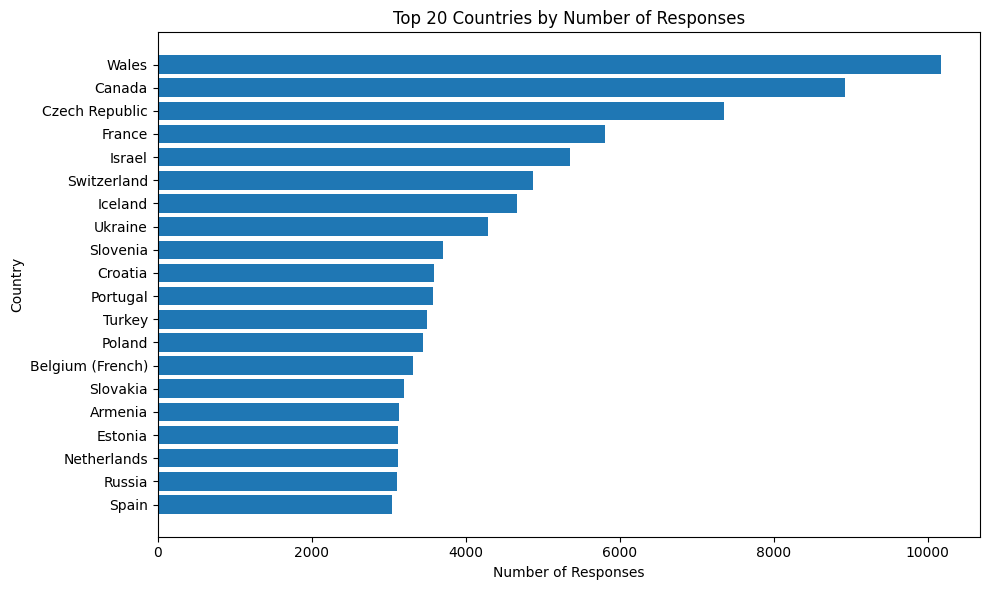

In [6]:
# ============================================================
# 5.1 DISTRIBUTION OF RESPONSES BY COUNTRY
# ============================================================
# Country mapping
country_map = {
    8000:"Albania",31000:"Azerbaijan",40000:"Austria",51000:"Armenia",
    56001:"Belgium (Flemish)",56002:"Belgium (French)",100000:"Bulgaria",
    124000:"Canada",191000:"Croatia",203000:"Czech Republic",208000:"Denmark",
    233000:"Estonia",246000:"Finland",250000:"France",268000:"Georgia",
    276000:"Germany",300000:"Greece",304000:"Greenland",348000:"Hungary",
    352000:"Iceland",372000:"Ireland",376000:"Israel",380000:"Italy",
    398000:"Kazakhstan",428000:"Latvia",440000:"Lithuania",442000:"Luxembourg",
    470000:"Malta",498000:"Republic of Moldova",528000:"Netherlands",
    578000:"Norway",616000:"Poland",620000:"Portugal",642000:"Romania",
    643000:"Russia",688000:"Serbia",703000:"Slovakia",705000:"Slovenia",
    724000:"Spain",752000:"Sweden",756000:"Switzerland",792000:"Turkey",
    804000:"Ukraine",807000:"Macedonia",826001:"England",826002:"Scotland",
    826003:"Wales",826004:"Northern Ireland",840000:"USA"
}
# ----------------------------
# 5.1.1 Prepare country variable
# ----------------------------
# Convert to numeric in case of any residual string values
df_country = df_clean[["countryno"]].copy()
df_country["countryno"] = pd.to_numeric(df_country["countryno"], errors="coerce")

# Drop rows where country is missing
df_country = df_country.dropna(subset=["countryno"])

print("Rows with valid country:", len(df_country))

# ----------------------------
# 5.1.2 Map country codes to names
# ----------------------------
# Use country_map dictionary
df_country["country_name"] = df_country["countryno"].map(country_map)

# Check for any unmapped country codes
n_missing_map = df_country["country_name"].isna().sum()

print(f"Unmapped country codes: {n_missing_map}")

# ----------------------------
# 5.1.3 Compute distribution
# ----------------------------
# Count number of responses per country
country_counts = df_country["country_name"].value_counts()

# Convert to percentage for easier interpretation
country_pct = df_country["country_name"].value_counts(normalize=True) * 100

# Combine into one table
country_dist = pd.DataFrame({
    "count": country_counts,
    "percentage": country_pct
})

# Sort by count (descending)
country_dist = country_dist.sort_values(by="count", ascending=False)

display(country_dist.head(15))

# ----------------------------
# 5.1.4 Plot distribution
# ----------------------------
import matplotlib.pyplot as plt

# Plot top 20 countries for readability
top_n = 20
plot_data = country_dist.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(plot_data.index[::-1], plot_data["count"][::-1])  # reverse for descending order

plt.xlabel("Number of Responses")
plt.ylabel("Country")
plt.title("Top 20 Countries by Number of Responses")

plt.tight_layout()
plt.show()

## 5.2 Distribution of Psychsomatic Variables (used to construct distress score)
Objective: 
Understand the raw signal behind distress score:
how each component is distributed
whether scales are used properly
whether there are skews / anomalies

 - 5.2.1 Convert to numeric
 - 5.2.2 Enforce valid ranges (just-in-time cleaning)
 - 5.2.3 Plot distributions (with scale interpretation)

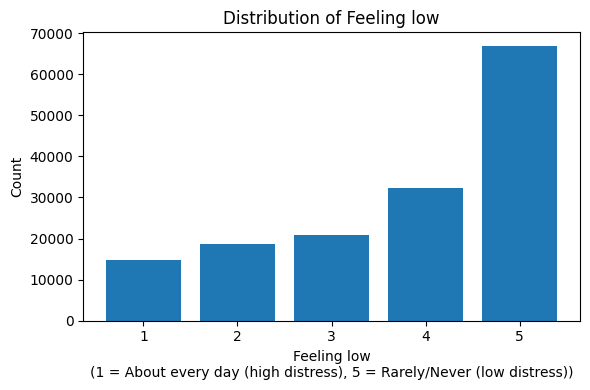

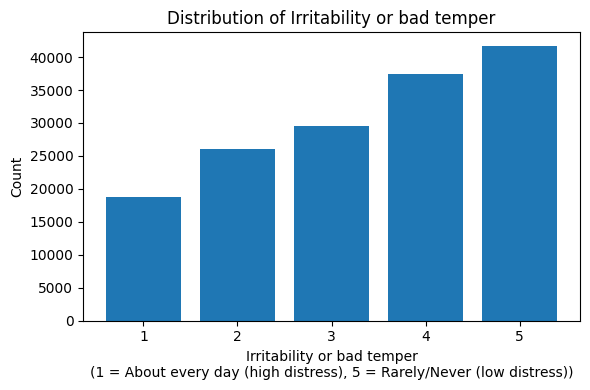

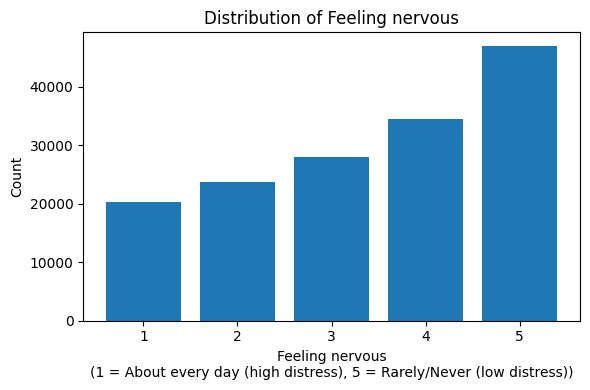

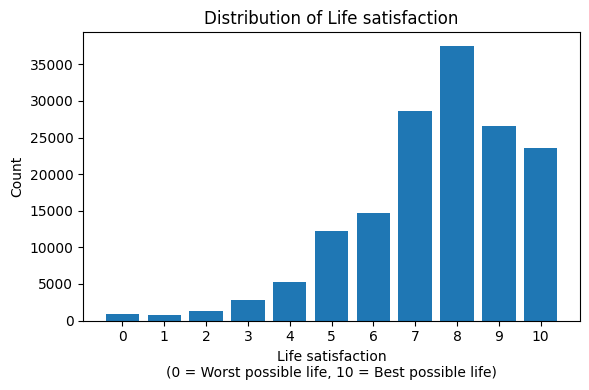

In [7]:
# ============================================================
# 5.2 DISTRIBUTION OF PSYCHOSOMATIC VARIABLES
# ============================================================

import matplotlib.pyplot as plt

# Distress components
psych_vars = ["feellow", "irritable", "nervous", "lifesat"]

# Create a working copy for EDA
df_psych = df_clean[psych_vars].copy()

# ----------------------------
# 5.2.1 Convert to numeric
# ----------------------------
# Ensure clean numeric values before plotting
for col in psych_vars:
    df_psych[col] = pd.to_numeric(df_psych[col], errors="coerce")

# ----------------------------
# 5.2.2 Enforce valid ranges (just-in-time cleaning)
# ----------------------------
# Apply scale constraints again to ensure EDA integrity

# Symptom variables (1–5)
for col in ["feellow", "irritable", "nervous"]:
    df_psych.loc[~df_psych[col].between(1, 5), col] = np.nan

# Life satisfaction (0–10)
df_psych.loc[~df_psych["lifesat"].between(0, 10), "lifesat"] = np.nan

# ----------------------------
# 5.2.3 Plot distributions (with scale interpretation)
# ----------------------------

# Define scale descriptions for clarity in plots
scale_desc = {
    "feellow": "1 = About every day (high distress), 5 = Rarely/Never (low distress)",
    "irritable": "1 = About every day (high distress), 5 = Rarely/Never (low distress)",
    "nervous": "1 = About every day (high distress), 5 = Rarely/Never (low distress)",
    "lifesat": "0 = Worst possible life, 10 = Best possible life"
}

for col in psych_vars:
    
    # Drop missing values for the current variable
    df_plot = df_psych[[col]].dropna()
    
    plt.figure(figsize=(6, 4))
    
    # Compute counts
    counts = df_plot[col].value_counts().sort_index()
    
    plt.bar(counts.index, counts.values)
    
    # Axis label includes BOTH variable meaning and scale direction
    plt.xlabel(f"{get_label(col)}\n({scale_desc[col]})")
    plt.ylabel("Count")
    
    plt.title(f"Distribution of {get_label(col)}")
    
    plt.xticks(counts.index)
    
    plt.tight_layout()
    plt.show()

## 5.3 Rank Countries by Distress Score
Objective: 
Compare average distress levels across countries
Identify:
high-distress regions
low-distress regions
Set up narrative for later analysis

 - 5.3.1 Prepare dataset
 - 5.3.2 Map country names
 - 5.3.3 Compute average distress by country
 - 5.3.4 Plot country ranking

Rows used for country distress analysis: 150867


,avg_distress
country_name,
Turkey,54.292995
Italy,44.677118
Greece,41.906821
Malta,41.467124
Poland,40.226091
Israel,40.102551
Sweden,39.419142
England,38.077021
Hungary,37.136628


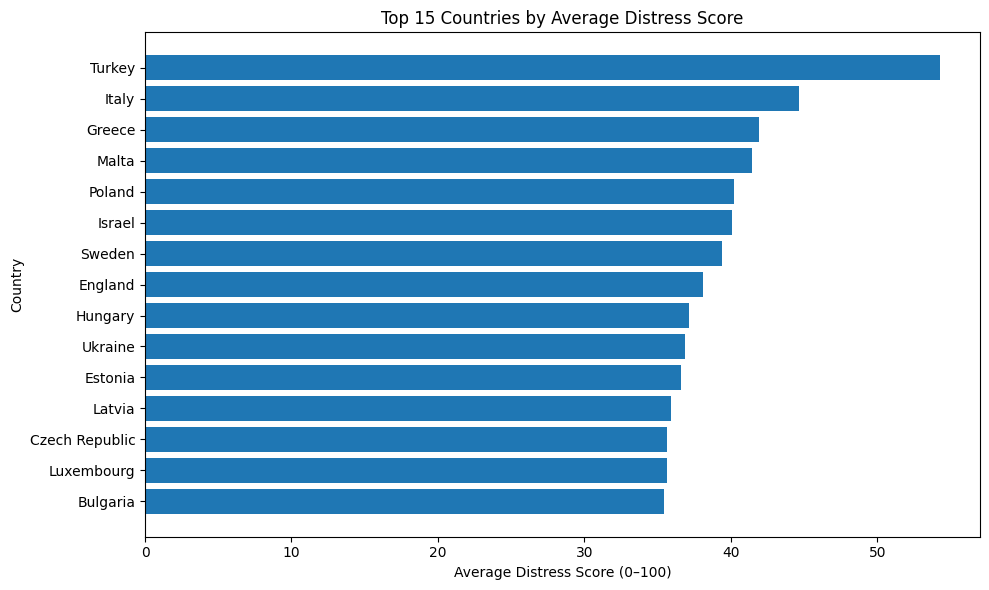

In [8]:
# ============================================================
# 5.3 RANK COUNTRIES BY DISTRESS SCORE
# ============================================================

# ----------------------------
# 5.3.1 Prepare dataset
# ----------------------------
# Keep only rows with both country and distress score
df_country_distress = df_clean[["countryno", "distress_score_100"]].copy()

df_country_distress["countryno"] = pd.to_numeric(df_country_distress["countryno"], errors="coerce")

# Drop missing values
df_country_distress = df_country_distress.dropna(subset=["countryno", "distress_score_100"])

print("Rows used for country distress analysis:", len(df_country_distress))

# ----------------------------
# 5.3.2 Map country names
# ----------------------------
df_country_distress["country_name"] = df_country_distress["countryno"].map(country_map)

# Drop any unmapped countries (if any)
df_country_distress = df_country_distress.dropna(subset=["country_name"])

# ----------------------------
# 5.3.3 Compute average distress by country
# ----------------------------
country_mean_distress = (
    df_country_distress
    .groupby("country_name")["distress_score_100"]
    .mean()
    .sort_values(ascending=False)
)

# Convert to DataFrame for easier viewing
country_mean_distress = country_mean_distress.to_frame(name="avg_distress")

display(country_mean_distress.head(10))

# ----------------------------
# 5.3.4 Plot country ranking
# ----------------------------
import matplotlib.pyplot as plt

# Plot top 15 highest distress countries
top_n = 15
plot_data = country_mean_distress.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(plot_data.index[::-1], plot_data["avg_distress"][::-1])

plt.xlabel("Average Distress Score (0–100)")
plt.ylabel("Country")
plt.title("Top 15 Countries by Average Distress Score")

plt.tight_layout()
plt.show()

## 5.4 Average Distress Score by Age
Objective: 
Understand how distress changes with age (13 -> 16.5)

 - 5.4.1 Prepare dataset
 - 5.4.2 Raw age trend
 - 5.4.3 Binned age trend (0.5-year bins)

Rows used for age analysis: 150867


,age,mean,count
0,13.000000,29.804019,3508
1,13.083333,29.161100,2919
2,13.083333,27.962846,1191
3,13.166667,31.148362,824
4,13.166667,29.651087,3819
...,...,...,...
66,16.333333,36.820843,427
67,16.333333,32.537313,67
68,16.416667,36.361940,67
69,16.416667,39.862069,145


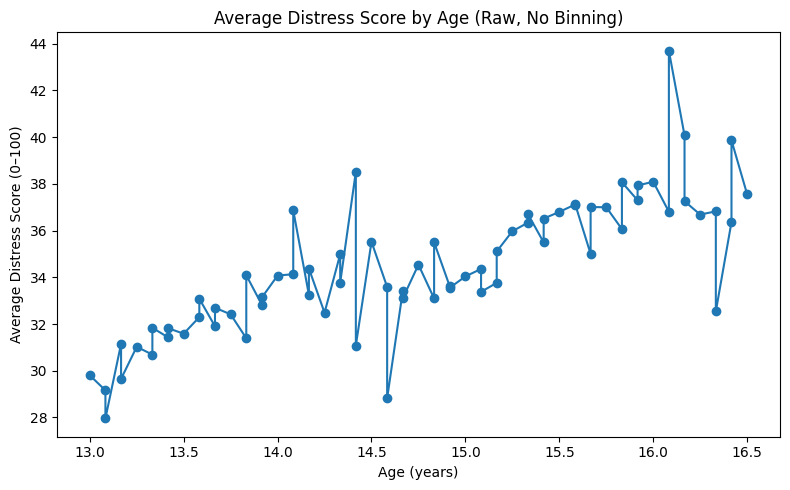

,age_bin_str,mean,count
0,"(12.999, 13.5]",30.739946,36479
1,"(13.5, 14.0]",32.698034,34003
2,"(14.0, 14.5]",34.239215,5772
3,"(14.5, 15.0]",33.775657,8331
4,"(15.0, 15.5]",35.865976,30750
5,"(15.5, 16.0]",37.104787,30686
6,"(16.0, 16.5]",37.925867,4846


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


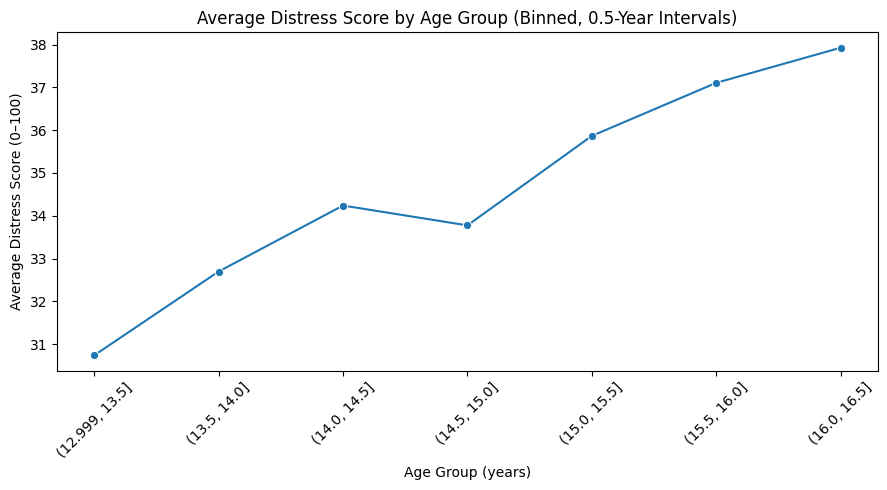

In [9]:
# ============================================================
# 5.4 AVERAGE DISTRESS SCORE BY AGE
# ============================================================

# ----------------------------
# 5.4.1 Prepare dataset
# ----------------------------
# Keep only relevant columns
df_age = df_clean[["age", "distress_score_100"]].copy()

# Convert to numeric (safe guard)
df_age["age"] = pd.to_numeric(df_age["age"], errors="coerce")

# Drop missing values
df_age = df_age.dropna(subset=["age", "distress_score_100"])

print("Rows used for age analysis:", len(df_age))

# ----------------------------
# 5.4.2 Raw age trend
# ----------------------------

age_summary = (
    df_age
    .groupby("age")["distress_score_100"]
    .agg(["mean", "count"])
    .reset_index()
)

age_summary = age_summary.sort_values(by="age")

display(age_summary)

plt.figure(figsize=(8, 5))

plt.plot(age_summary["age"], age_summary["mean"], marker="o")

plt.xlabel("Age (years)")
plt.ylabel("Average Distress Score (0–100)")
plt.title("Average Distress Score by Age (Raw, No Binning)")

plt.tight_layout()
plt.show()

# ----------------------------
# 5.4.3 Binned age trend (0.5-year bins)
# ----------------------------

import numpy as np
import seaborn as sns

# Create bins (ensure 16.5 included)
bins = np.arange(13, 16.5 + 0.5, 0.5)

df_age_bin = df_age.copy()

# Create bins
df_age_bin["age_bin"] = pd.cut(df_age_bin["age"], bins=bins, include_lowest=True)

# Convert to string for plotting
df_age_bin["age_bin_str"] = df_age_bin["age_bin"].astype(str)

# Compute mean + count
age_bin_summary = (
    df_age_bin.groupby("age_bin_str")["distress_score_100"]
    .agg(["mean", "count"])
    .reset_index()
)

display(age_bin_summary)

# Plot
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=age_bin_summary,
    x="age_bin_str",
    y="mean",
    marker="o"
)

plt.xlabel("Age Group (years)")
plt.ylabel("Average Distress Score (0–100)")
plt.title("Average Distress Score by Age Group (Binned, 0.5-Year Intervals)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5.5 Distribution of Distress Score
Objective: 
Undestand overall distribution of distress
Define risk tiers (low/moderate/high)

 - 5.5.1 Prepare dataset
 - 5.5.2 Compute percentile thresholds
 - 5.5.3 Plot distribution
 - 5.5.4 Assign risk groups

Rows used: 150867
75th percentile: 50.00
85th percentile: 62.50


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


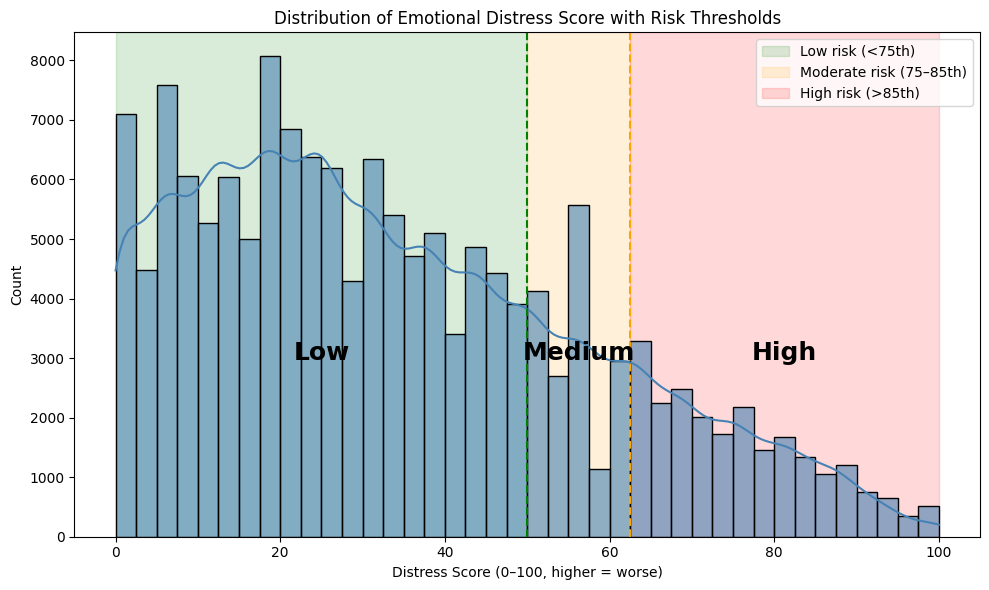

Risk group distribution (%):
risk_group
Low         73.89
High        15.19
Moderate    10.92
Name: proportion, dtype: float64


In [10]:
# ============================================================
# 5.5 DISTRIBUTION OF DISTRESS SCORE + PERCENTILE THRESHOLDS
# ============================================================
# ----------------------------
# 5.5.1 Prepare dataset
# ----------------------------
df_dist = df_clean[["distress_score_100"]].copy()
df_dist = df_dist.dropna(subset=["distress_score_100"])

print("Rows used:", len(df_dist))

# ----------------------------
# 5.5.2 Compute percentile thresholds
# ----------------------------
p75 = df_dist["distress_score_100"].quantile(0.75)
p85 = df_dist["distress_score_100"].quantile(0.85)

print(f"75th percentile: {p75:.2f}")
print(f"85th percentile: {p85:.2f}")


# ----------------------------
# 5.5.3 Plot distribution
# ----------------------------
plt.figure(figsize=(10, 6))

# Shade regions
plt.axvspan(0, p75, color="green", alpha=0.15, label="Low risk (<75th)")
plt.axvspan(p75, p85, color="orange", alpha=0.15, label="Moderate risk (75–85th)")
plt.axvspan(p85, 100, color="red", alpha=0.15, label="High risk (>85th)")

# Create bins with width = 2.5
bin_edges = np.arange(0, 100 + 2.5, 2.5)

sns.histplot(
    df_dist["distress_score_100"],
    bins=bin_edges,
    kde=True,
    color="steelblue",
    edgecolor="black",
    alpha=0.6
)

# Threshold lines
plt.axvline(p75, linestyle="--", color="green", linewidth=1.5)
plt.axvline(p85, linestyle="--", color="orange", linewidth=1.5)

# Add text labels inside regions
ymax = plt.ylim()[1]

plt.text(p75 / 2, ymax * 0.35, "Low", ha="center", fontsize=18, fontweight="bold")
plt.text((p75 + p85) / 2, ymax * 0.35, "Medium", ha="center", fontsize=18, fontweight="bold")
plt.text((p85 + 100) / 2, ymax * 0.35, "High", ha="center", fontsize=18, fontweight="bold")

# Labels
plt.xlabel("Distress Score (0–100, higher = worse)")
plt.ylabel("Count")
plt.title("Distribution of Emotional Distress Score with Risk Thresholds")

plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 5.5.4 Assign risk groups
# ----------------------------
def risk_group(x):
    if x < p75:
        return "Low"
    elif x < p85:
        return "Moderate"
    else:
        return "High"

df_dist["risk_group"] = df_dist["distress_score_100"].apply(risk_group)

risk_dist = df_dist["risk_group"].value_counts(normalize=True).mul(100).round(2)

print("Risk group distribution (%):")
print(risk_dist)

## 5.6 Top Predictors of Distress (Correlation)
Objective: 
Identify variables most associated with distress

 - 5.6.1 Define columns to exclude
 - 5.6.2 Build candidate predictor list
 - 5.6.3 Prepare correlation dataset
 - 5.6.4 Compute correlations with distress score
 - 5.6.5 Visualise top 20 predictors

Number of candidate predictors: 97
Rows used for correlation analysis: 150867


,variable,correlation,abs_correlation,n_used
0,sleepdificulty,-0.458658,0.458658,147935
1,headache,-0.438586,0.438586,150778
2,dizzy,-0.425776,0.425776,149929
3,stomachache,-0.397150,0.397150,150693
4,health,0.351853,0.351853,150148
5,backache,-0.346021,0.346021,150561
6,schoolpressure,0.315559,0.315559,148625
7,talkfather,0.289312,0.289312,142521
8,famtalk,-0.282939,0.282939,141210
9,studaccept,0.281196,0.281196,141798


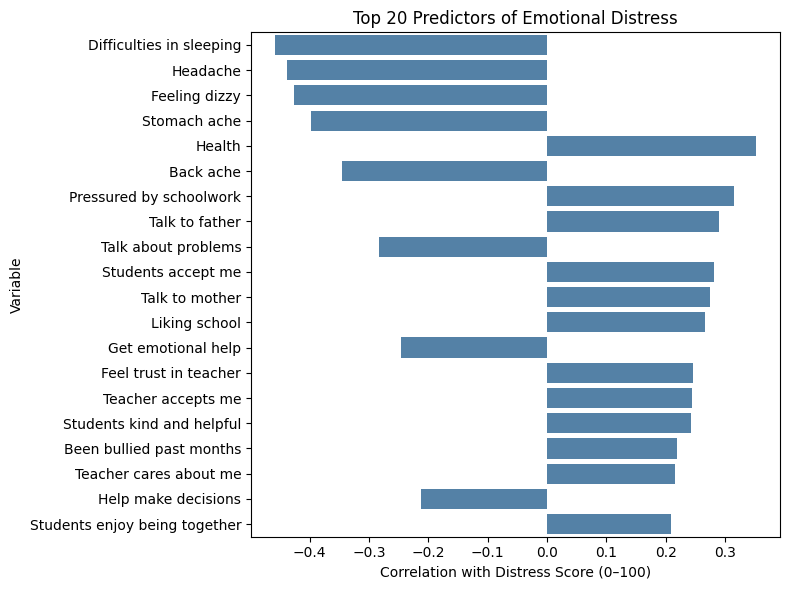

In [11]:
# ============================================================
# 5.6 TOP PREDICTORS OF DISTRESS (CORRELATION ANALYSIS)
# ============================================================

# ----------------------------
# 5.6.1 Define columns to exclude
# ----------------------------
# Exclude identifiers, admin variables, demographics, and all target-related columns
exclude_cols = [

    # IDs / admin
    "seqno_int", "cluster", "id1", "id2", "id3", "id4",
    "HBSC", "region", "countryno", "month", "year", "weight", "adm",

    # demographics
    "age", "agecat", "sex", "grade", "monthbirth", "yearbirth",

    # raw Y variables
    "feellow", "irritable", "nervous", "lifesat",

    # reversed Y variables
    "feellow_rev", "irritable_rev", "nervous_rev", "lifesat_rev",

    # scaled Y variables
    "feellow_rev_scaled", "irritable_rev_scaled", "nervous_rev_scaled", "lifesat_rev_scaled",

    # composite outcomes
    "distress_score_100", "distress_score_z"
]

# ----------------------------
# 5.6.2 Build candidate predictor list
# ----------------------------
# Keep only columns not in the exclusion list
candidate_cols = [c for c in df_clean.columns if c not in exclude_cols]

print("Number of candidate predictors:", len(candidate_cols))

# ----------------------------
# 5.6.3 Prepare correlation dataset
# ----------------------------
# Work only with candidate predictors plus the target column
df_corr = df_clean[candidate_cols + ["distress_score_100"]].copy()

# Convert all candidate predictors to numeric just before use
# Non-numeric values will become NaN
for col in candidate_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Drop rows with missing target
df_corr = df_corr.dropna(subset=["distress_score_100"])

print("Rows used for correlation analysis:", len(df_corr))

# ----------------------------
# 5.6.4 Compute correlations with distress score
# ----------------------------
# For each candidate variable, compute Pearson correlation with distress_score_100
corr_rows = []

for col in candidate_cols:
    
    # Keep only rows where both the predictor and target are present
    df_pair = df_corr[[col, "distress_score_100"]].dropna()
    
    # Skip variables with too few usable rows
    if len(df_pair) < 30:
        continue
    
    # Skip variables with no variation
    if df_pair[col].nunique() <= 1:
        continue
    
    # Compute correlation
    corr_value = df_pair[col].corr(df_pair["distress_score_100"])
    
    corr_rows.append({
        "variable": col,
        "correlation": corr_value,
        "abs_correlation": abs(corr_value),
        "n_used": len(df_pair)
    })

corr_df_model = pd.DataFrame(corr_rows)

# Sort by absolute correlation strength
corr_df_model = corr_df_model.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

display(corr_df_model.head(20))

# ----------------------------
# 5.6.5 Visualise top 20 predictors
# ----------------------------
# Keep the top 20 strongest predictors by absolute correlation
top20_model = corr_df_model.head(20).copy()

# Map variable names to human-readable labels
top20_model["label"] = top20_model["variable"].map(get_label)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top20_model,
    x="correlation",
    y="label",
    color="steelblue"
)

plt.title("Top 20 Predictors of Emotional Distress")
plt.xlabel("Correlation with Distress Score (0–100)")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 5.7 Sleep Difficulty vs Distress
Objective: 
Show how distress changes across sleep difficulty levels
 

 - 5.7.1 Prepare dataset
 - 5.7.2 Compute percentile thresholds
 - 5.7.3 Plot boxplot with risk regions

Rows used for sleep analysis: 147935
75th percentile: 50.00
85th percentile: 62.50


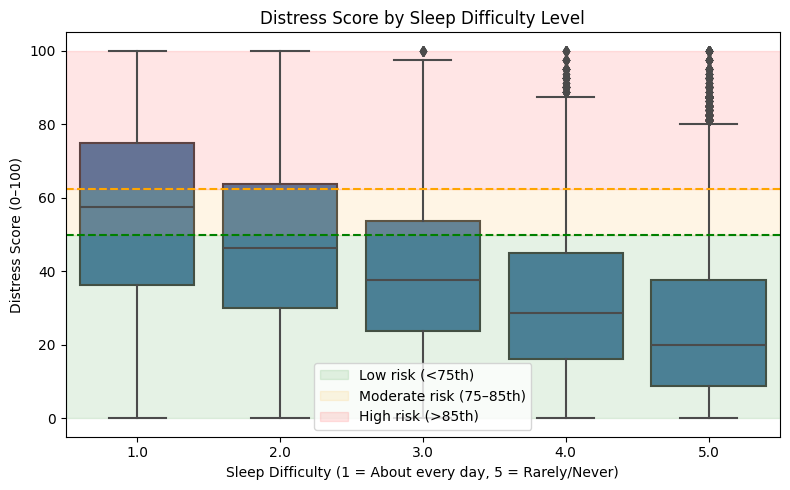

In [12]:
# ============================================================
# 5.7 SLEEP DIFFICULTY VS DISTRESS
# ============================================================

# ----------------------------
# 5.7.1 Prepare dataset
# ----------------------------
df_sleep = df_clean[["sleepdificulty", "distress_score_100"]].copy()

# Convert to numeric
df_sleep["sleepdificulty"] = pd.to_numeric(df_sleep["sleepdificulty"], errors="coerce")

# Keep valid scale values only (1–5)
df_sleep.loc[~df_sleep["sleepdificulty"].between(1, 5), "sleepdificulty"] = np.nan

# Drop missing values
df_sleep = df_sleep.dropna(subset=["sleepdificulty", "distress_score_100"])

print("Rows used for sleep analysis:", len(df_sleep))

# ----------------------------
# 5.7.2 Compute percentile thresholds
# ----------------------------
p75 = df_clean["distress_score_100"].dropna().quantile(0.75)
p85 = df_clean["distress_score_100"].dropna().quantile(0.85)

print(f"75th percentile: {p75:.2f}")
print(f"85th percentile: {p85:.2f}")

# ----------------------------
# 5.7.3 Plot boxplot with risk regions
# ----------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sleep,
    x="sleepdificulty",
    y="distress_score_100",
    color="steelblue"
)

# Shade regions with labels (for legend)
plt.axhspan(0, p75, color="green", alpha=0.1, label="Low risk (<75th)")
plt.axhspan(p75, p85, color="orange", alpha=0.1, label="Moderate risk (75–85th)")
plt.axhspan(p85, df_sleep["distress_score_100"].max(), color="red", alpha=0.1, label="High risk (>85th)")

# Threshold lines
plt.axhline(p75, linestyle="--", color="green", linewidth=1.5)
plt.axhline(p85, linestyle="--", color="orange", linewidth=1.5)

plt.xlabel("Sleep Difficulty (1 = About every day, 5 = Rarely/Never)")
plt.ylabel("Distress Score (0–100)")
plt.title("Distress Score by Sleep Difficulty Level")

plt.legend()
plt.tight_layout()
plt.show()

## 5.8 School Pressure vs Distress
Objective: 
Show how distress varies with perceived school pressure

 - 5.8.1 Prepare dataset
 - 5.8.2 Plot boxplot with risk regions

Rows used for school pressure analysis: 148625


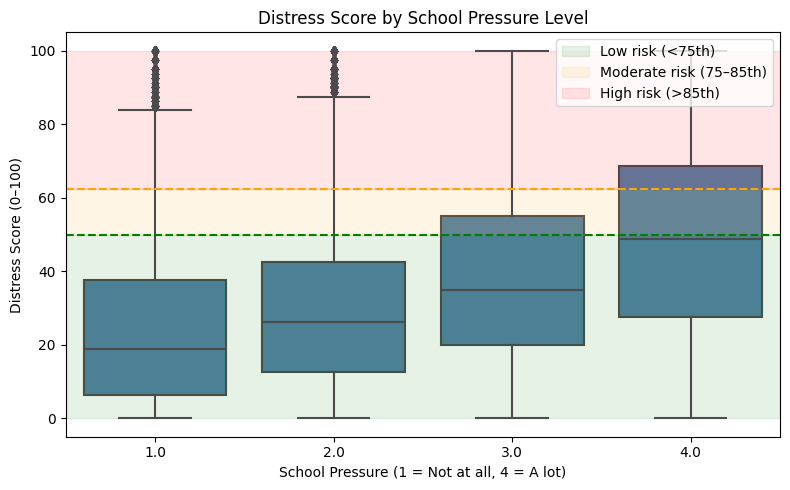

In [13]:
# ============================================================
# 5.8 SCHOOL PRESSURE VS DISTRESS
# ============================================================

# ----------------------------
# 5.8.1 Prepare dataset
# ----------------------------
df_pressure = df_clean[["schoolpressure", "distress_score_100"]].copy()

# Convert to numeric
df_pressure["schoolpressure"] = pd.to_numeric(df_pressure["schoolpressure"], errors="coerce")

# Valid scale: 1–4
df_pressure.loc[~df_pressure["schoolpressure"].between(1, 4), "schoolpressure"] = np.nan

# Drop missing
df_pressure = df_pressure.dropna(subset=["schoolpressure", "distress_score_100"])

print("Rows used for school pressure analysis:", len(df_pressure))


# ----------------------------
# 5.8.2 Plot boxplot with risk regions
# ----------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_pressure,
    x="schoolpressure",
    y="distress_score_100",
    color="steelblue"
)

# Shade regions with SAME labels
plt.axhspan(0, p75, color="green", alpha=0.1, label="Low risk (<75th)")
plt.axhspan(p75, p85, color="orange", alpha=0.1, label="Moderate risk (75–85th)")
plt.axhspan(p85, df_pressure["distress_score_100"].max(), color="red", alpha=0.1, label="High risk (>85th)")

# Threshold lines
plt.axhline(p75, linestyle="--", color="green", linewidth=1.5)
plt.axhline(p85, linestyle="--", color="orange", linewidth=1.5)

plt.xlabel("School Pressure (1 = Not at all, 4 = A lot)")
plt.ylabel("Distress Score (0–100)")
plt.title("Distress Score by School Pressure Level")

plt.legend()
plt.tight_layout()
plt.show()

## 5.9 Family Support vs Distress
Objective: 
Show how family support relates to distress

 - 5.9.1 Prepare dataset
 - 5.9.2 Plot boxplot with risk regions

Rows used for family support analysis: 141205


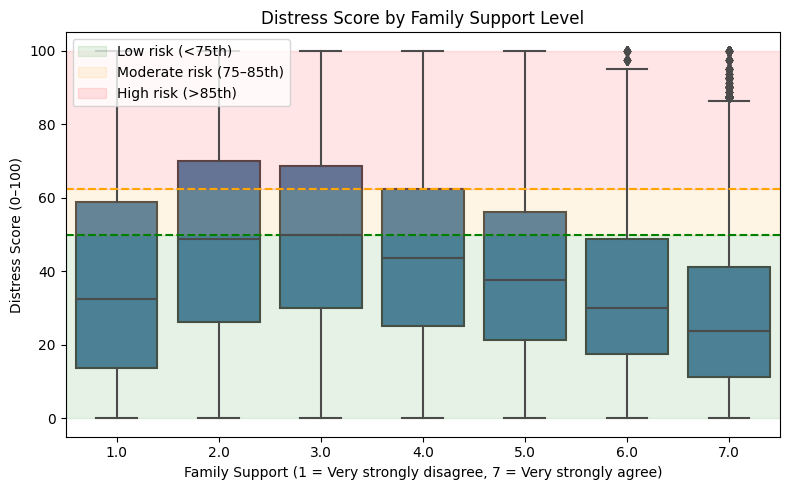

In [14]:
# ============================================================
# 5.9 FAMILY SUPPORT VS DISTRESS (WITH RISK THRESHOLDS)
# ============================================================

# ----------------------------
# 5.9.1 Prepare dataset
# ----------------------------
df_fam = df_clean[["famsup", "distress_score_100"]].copy()

# Convert to numeric
df_fam["famsup"] = pd.to_numeric(df_fam["famsup"], errors="coerce")

# Valid scale: 1–7 (HBSC family support scale)
df_fam.loc[~df_fam["famsup"].between(1, 7), "famsup"] = np.nan

# Drop missing
df_fam = df_fam.dropna(subset=["famsup", "distress_score_100"])

print("Rows used for family support analysis:", len(df_fam))

# ----------------------------
# 5.9.2 Plot boxplot with risk regions
# ----------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_fam,
    x="famsup",
    y="distress_score_100",
    color="steelblue"
)

# Shade risk regions (same thresholds)
plt.axhspan(0, p75, color="green", alpha=0.1, label="Low risk (<75th)")
plt.axhspan(p75, p85, color="orange", alpha=0.1, label="Moderate risk (75–85th)")
plt.axhspan(p85, df_fam["distress_score_100"].max(), color="red", alpha=0.1, label="High risk (>85th)")

# Threshold lines
plt.axhline(p75, linestyle="--", color="green", linewidth=1.5)
plt.axhline(p85, linestyle="--", color="orange", linewidth=1.5)

# Labels (VERY important for interpretation)
plt.xlabel("Family Support (1 = Very strongly disagree, 7 = Very strongly agree)")
plt.ylabel("Distress Score (0–100)")
plt.title("Distress Score by Family Support Level")

plt.legend()
plt.tight_layout()
plt.show()

## 5.10 Family Support Category vs Distress
Objective: 
Show how family support binning relate to distress

 - 5.10.1 Prepare dataset
 - 5.10.2 Create categories
 - 5.10.3 Plot boxplot with risk regions

Rows used for family support category: 141205


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


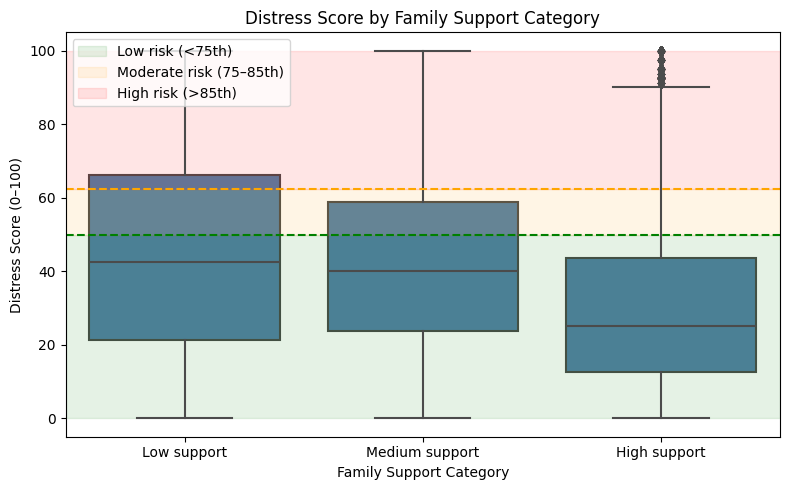

In [15]:
# ============================================================
# 5.10 FAMILY SUPPORT CATEGORY VS DISTRESS
# ============================================================

# ----------------------------
# 5.10.1 Prepare dataset
# ----------------------------
df_fam_cat = df_clean[["famsup", "distress_score_100"]].copy()

# Convert to numeric
df_fam_cat["famsup"] = pd.to_numeric(df_fam_cat["famsup"], errors="coerce")

# Valid scale: 1–7
df_fam_cat.loc[~df_fam_cat["famsup"].between(1, 7), "famsup"] = np.nan

# Drop missing
df_fam_cat = df_fam_cat.dropna(subset=["famsup", "distress_score_100"])

print("Rows used for family support category:", len(df_fam_cat))

# ----------------------------
# 5.10.2 Create categories
# ----------------------------
# Define interpretable groups

def famsup_category(x):
    if x <= 3:
        return "Low support"
    elif x <= 5:
        return "Medium support"
    else:
        return "High support"

df_fam_cat["famsup_cat"] = df_fam_cat["famsup"].apply(famsup_category)

# Ensure logical ordering
df_fam_cat["famsup_cat"] = pd.Categorical(
    df_fam_cat["famsup_cat"],
    categories=["Low support", "Medium support", "High support"],
    ordered=True
)

# ----------------------------
# 5.10.3 Plot boxplot with consistent styling
# ----------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_fam_cat,
    x="famsup_cat",
    y="distress_score_100",
    color="steelblue"
)

# Shade risk regions
plt.axhspan(0, p75, color="green", alpha=0.1, label="Low risk (<75th)")
plt.axhspan(p75, p85, color="orange", alpha=0.1, label="Moderate risk (75–85th)")
plt.axhspan(p85, df_fam_cat["distress_score_100"].max(), color="red", alpha=0.1, label="High risk (>85th)")

# Threshold lines
plt.axhline(p75, linestyle="--", color="green", linewidth=1.5)
plt.axhline(p85, linestyle="--", color="orange", linewidth=1.5)

# Labels
plt.xlabel("Family Support Category")
plt.ylabel("Distress Score (0–100)")
plt.title("Distress Score by Family Support Category")

plt.legend()
plt.tight_layout()
plt.show()

## 5.11 Bullying experience vs Distress
Objective: 
Show how bullying relate to distress

 - 5.11.1 Prepare dataset
 - 5.11.2 Plot boxplot with risk regions

Rows used for bullying analysis: 142082


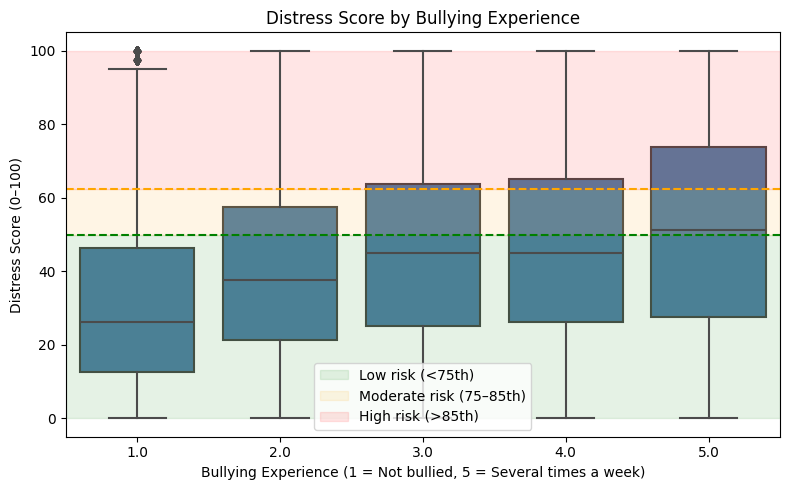

In [16]:
# ============================================================
# 5.11 BULLYING EXPERIENCE VS DISTRESS
# ============================================================

# ----------------------------
# 5.11.1 Prepare dataset
# ----------------------------
df_bully = df_clean[["beenbullied", "distress_score_100"]].copy()

# Convert to numeric
df_bully["beenbullied"] = pd.to_numeric(df_bully["beenbullied"], errors="coerce")

# Valid scale: 1–5
df_bully.loc[~df_bully["beenbullied"].between(1, 5), "beenbullied"] = np.nan

# Drop missing
df_bully = df_bully.dropna(subset=["beenbullied", "distress_score_100"])

print("Rows used for bullying analysis:", len(df_bully))

# ----------------------------
# 5.11.2 Plot boxplot with risk regions
# ----------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_bully,
    x="beenbullied",
    y="distress_score_100",
    color="steelblue"
)

# Shade risk regions using the same thresholds as the distress distribution plot
plt.axhspan(0, p75, color="green", alpha=0.1, label="Low risk (<75th)")
plt.axhspan(p75, p85, color="orange", alpha=0.1, label="Moderate risk (75–85th)")
plt.axhspan(p85, df_bully["distress_score_100"].max(), color="red", alpha=0.1, label="High risk (>85th)")

# Add threshold lines
plt.axhline(p75, linestyle="--", color="green", linewidth=1.5)
plt.axhline(p85, linestyle="--", color="orange", linewidth=1.5)

# Labels
plt.xlabel("Bullying Experience (1 = Not bullied, 5 = Several times a week)")
plt.ylabel("Distress Score (0–100)")
plt.title("Distress Score by Bullying Experience")

plt.legend()
plt.tight_layout()
plt.show()

# 6 Workbook-Driven Feature Engineering
Objective: 
Translate raw variables into model-ready features
• Apply:
 • grouping rules
 • aggregation logic
 • inclusion/exclusion flags
• Produce:
 • feature_df
 • df_model
 • feature_manifest

- 6.1 Load feature plan (Excel)
- 6.2 Feature construction logic
- 6.3 Build feature matrix
- 6.4 Apply feature engineering
- 6.5 Merge engineered features
- 6.6 Feature manifest
- 6.7 EDA on engineered (grouped) features

## 6.1 Load feature plan (Excel)
Objective: 
Load and clean feature plan

- 6.1.1 Helper functions
- 6.1.2 Load feature plan
- 6.1.3 Inspect aggregation methods
- 6.1.4 Check grouping consistency

In [17]:
import pandas as pd
import numpy as np
import re

GROUPINGS_PATH = "HBSC_data/hbsc_variable_groupings.xlsx" 


# ----------------------------
# 6.1.1 Helper functions
# ----------------------------

def clean_text(value):
    """
    Standardise text values:
    - convert to string
    - strip whitespace
    - remove stray quotes
    - convert NaN → empty string
    """
    if pd.isna(value):
        return ""
    return str(value).strip().strip("'").strip()


def slugify_group(name):
    """
    Convert group name into safe column name.
    Example:
    'Family Support' → 'family_support'
    """
    slug = re.sub(r"[^0-9a-zA-Z]+", "_", clean_text(name).lower()).strip("_")
    return slug or "unnamed"


# ----------------------------
# 6.1.2 Load feature plan
# ----------------------------

# Read Excel
feature_plan = pd.read_excel(GROUPINGS_PATH).iloc[:, :6].copy()

# Rename columns to consistent internal names
feature_plan.columns = [
    "hbsc_var",              # original variable
    "new_group",             # grouping name
    "aggregation_method",    # aggregation rule
    "new_question",          # description
    "omit_for_modelling",    # Y/N
    "long_term_var",         # Y/N
]

# Clean all text fields
for col in feature_plan.columns:
    feature_plan[col] = feature_plan[col].map(clean_text)

# Remove empty rows (no variable)
feature_plan = feature_plan[feature_plan["hbsc_var"] != ""].reset_index(drop=True)

print("Feature plan loaded and cleaned.")
print("Number of rows:", len(feature_plan))

# ----------------------------
# 6.1.3 Inspect aggregation methods
# ----------------------------
print("\nAggregation methods found:")
print(feature_plan["aggregation_method"].unique())

# ----------------------------
# 6.1.4 Check grouping consistency
# ----------------------------
group_method_check = (
    feature_plan[feature_plan["new_group"] != ""]
    .groupby("new_group")["aggregation_method"]
    .apply(lambda s: sorted(set(x for x in s if x != "")))
    .reset_index(name="methods_found")
)

group_method_check["n_methods"] = group_method_check["methods_found"].apply(len)

print("\nGroups with multiple aggregation methods (should be none):")
display(group_method_check[group_method_check["n_methods"] > 1])

Feature plan loaded and cleaned.
Number of rows: 120

Aggregation methods found:
['' 'take the most frequent out of all the symptoms' 'sum - 2' 'mean'
 'take the most frequent' 'at least 1 yes = new yes']

Groups with multiple aggregation methods (should be none):


,new_group,methods_found,n_methods


## 6.2 Feature construction logic

In [18]:
# ----------------------------
# 6.2.1 Helper functions
# ----------------------------

def first_nonempty(values, default=""):
    """
    Return the first non-empty value from a list/Series.
    Used to extract group-level metadata.
    """
    for value in values:
        value = clean_text(value)
        if value:
            return value
    return default

# ----------------------------
# 6.2.2 Aggregation logic (complete-case)
# ----------------------------

def aggregate_feature_complete_case(df_source, source_cols, method):
    """
    Aggregate grouped features using complete-case logic:
    - If ANY constituent variable is missing → output NaN
    - Otherwise apply the specified aggregation rule
    """

    numeric = pd.DataFrame(index=df_source.index)

    # Convert all source columns to numeric
    for col in source_cols:
        if col in df_source.columns:
            numeric[col] = pd.to_numeric(df_source[col], errors="coerce")
        else:
            numeric[col] = np.nan

    # Complete-case mask
    complete_mask = numeric.notna().all(axis=1)

    # Initialise output
    out = pd.Series(np.nan, index=df_source.index, dtype=float)

    # ------------------------
    # Mean aggregation
    # ------------------------
    if method == "mean":
        out.loc[complete_mask] = numeric.loc[complete_mask].mean(axis=1)
        return out

    # ------------------------
    # Sum-adjusted (breakfast logic)
    # ------------------------
    if method == "sum - 2":
        counts = numeric.loc[complete_mask].notna().sum(axis=1)
        summed = numeric.loc[complete_mask].sum(axis=1) - counts
        out.loc[complete_mask] = summed
        return out

    # ------------------------
    # Max aggregation (higher = worse)
    # ------------------------
    if method == "take the most frequent":
        out.loc[complete_mask] = numeric.loc[complete_mask].max(axis=1)
        return out

    # ------------------------
    # Min aggregation (lower = worse)
    # ------------------------
    if method == "take the most frequent out of all the symptoms":
        out.loc[complete_mask] = numeric.loc[complete_mask].min(axis=1)
        return out

    # ------------------------
    # Binary OR logic
    # ------------------------
    if method == "at least 1 yes = new yes":
        any_yes = numeric.loc[complete_mask].eq(1).any(axis=1)
        out.loc[complete_mask] = 2.0
        out.loc[complete_mask & any_yes] = 1.0
        return out

    # ------------------------
    # Raw fallback (single variable)
    # ------------------------
    if method == "" and len(source_cols) == 1:
        out.loc[complete_mask] = numeric.loc[complete_mask, source_cols[0]]
        return out

    raise ValueError(f"Unsupported aggregation method: {method!r}")

## 6.3 Build feature matrix

In [19]:
# ----------------------------
# 6.3.1 Build feature matrix
# ----------------------------

def build_feature_matrix(df_source, feature_plan):
    """
    Construct engineered features from feature plan.
    """

    keep_plan = feature_plan[feature_plan["omit_for_modelling"] == "N"].copy()

    feature_data = {}
    manifest_rows = []
    seen_features = set()

    for _, row in keep_plan.iterrows():

        raw_col = row["hbsc_var"]
        group_name = row["new_group"]

        # ------------------------
        # Grouped feature
        # ------------------------
        if group_name:
            feature_name = f"grp_{slugify_group(group_name)}"

            if feature_name in seen_features:
                continue

            group_rows = keep_plan[keep_plan["new_group"] == group_name]

            source_cols = group_rows["hbsc_var"].tolist()
            method = first_nonempty(group_rows["aggregation_method"])
            question = first_nonempty(group_rows["new_question"])

            long_term = "Y" if (group_rows["long_term_var"] == "Y").any() else "N"

            missing_cols = [c for c in source_cols if c not in df_source.columns]

            feature_data[feature_name] = aggregate_feature_complete_case(
                df_source, source_cols, method
            )

            manifest_rows.append({
                "feature": feature_name,
                "feature_type": "grouped",
                "source_cols": ", ".join(source_cols),
                "new_group": group_name,
                "aggregation_method": method,
                "long_term_var": long_term,
                "new_question": question,
                "missing_source_cols": ", ".join(missing_cols),
            })

            seen_features.add(feature_name)
            continue

        # ------------------------
        # Standalone feature
        # ------------------------
        if raw_col in seen_features:
            continue

        if raw_col in df_source.columns:
            feature_series = pd.to_numeric(df_source[raw_col], errors="coerce")
            missing_cols = []
        else:
            feature_series = pd.Series(np.nan, index=df_source.index, dtype=float)
            missing_cols = [raw_col]

        feature_data[raw_col] = feature_series

        manifest_rows.append({
            "feature": raw_col,
            "feature_type": "standalone",
            "source_cols": raw_col,
            "new_group": "",
            "aggregation_method": "raw",
            "long_term_var": row["long_term_var"] or "N",
            "new_question": row["new_question"],
            "missing_source_cols": ", ".join(missing_cols),
        })

        seen_features.add(raw_col)

    feature_df = pd.DataFrame(feature_data, index=df_source.index)
    feature_cols = list(feature_df.columns)
    feature_manifest = pd.DataFrame(manifest_rows)

    return feature_df, feature_cols, feature_manifest

## 6.4 Apply feature engineering

In [20]:
# ----------------------------
# 6.4 Apply feature engineering
# ----------------------------

df_model = df_clean.copy()

feature_df, feature_cols, feature_manifest = build_feature_matrix(
    df_source=df_model,
    feature_plan=feature_plan
)

print(f"Workbook rows kept for modelling: {(feature_plan['omit_for_modelling'] == 'N').sum()}")
print(f"Engineered feature count: {len(feature_cols)}")

Workbook rows kept for modelling: 72
Engineered feature count: 56


## 6.5 Merge engineered features

In [21]:
# ----------------------------
# 6.5 Merge engineered features
# ----------------------------

existing_feature_names = [c for c in feature_df.columns if c in df_model.columns]

df_model = df_model.drop(columns=existing_feature_names, errors="ignore")
df_model = pd.concat([df_model, feature_df], axis=1)

print("Final df_model shape:", df_model.shape)

# Rows with valid distress score
n_target = df_model["distress_score_100"].notna().sum()

print("Rows with target (max possible):", n_target)
# All features (grouped + standalone)
model_cols = feature_cols + ["distress_score_100"]

df_complete = df_model[model_cols].dropna()

print("Rows with complete features (strict):", len(df_complete))

Final df_model shape: (156603, 134)
Rows with target (max possible): 150867
Rows with complete features (strict): 65900


## 6.6 Feature manifest

In [22]:
# ----------------------------
# 6.6 Feature manifest
# ----------------------------

print("\nFeature manifest:")
display(feature_manifest)


Feature manifest:


,feature,feature_type,source_cols,new_group,aggregation_method,long_term_var,new_question,missing_source_cols
0,age,standalone,age,,raw,Y,,
1,sex,standalone,sex,,raw,Y,,
2,fasfamcar,standalone,fasfamcar,,raw,Y,,
3,fasbedroom,standalone,fasbedroom,,raw,Y,,
4,fascomputers,standalone,fascomputers,,raw,Y,,
5,fasbathroom,standalone,fasbathroom,,raw,Y,,
6,fasdishwash,standalone,fasdishwash,,raw,Y,,
7,fasholidays,standalone,fasholidays,,raw,Y,,
8,health,standalone,health,,raw,N,,
9,grp_aches,grouped,"headache, stomachache, backache, dizzy",aches,take the most frequent out of all the symptoms,N,"In the last 6 months, how often have you had a...",


## 6.7 EDA on engineered (grouped) features
Objective: 
Validate that grouped features behave as expected
Check that they preserve pattersn

- 6.7.1 Identify engineered features
- 6.7.2 Scale interpretation
- 6.7.3 Label mapping
- 6.7.4 Missingness analysis
- 6.7.5 Distribution plots
- 6.7.6 Correlation analysis
- 6.7.7 Top predictors
- 6.7.8 Boxplots (grouped features)

Total engineered features: 56
Grouped features: 12


,missing_pct
bodyweight,15.314521
bodyheight,14.152347
emcsocmed8,12.179205
emcsocmed9,12.135144
emcsocmed7,12.085975
emcsocmed6,12.066180
emcsocmed5,12.007433
grp_online_contact,11.994662
emcsocmed4,11.977421
grp_online_pref,11.918035


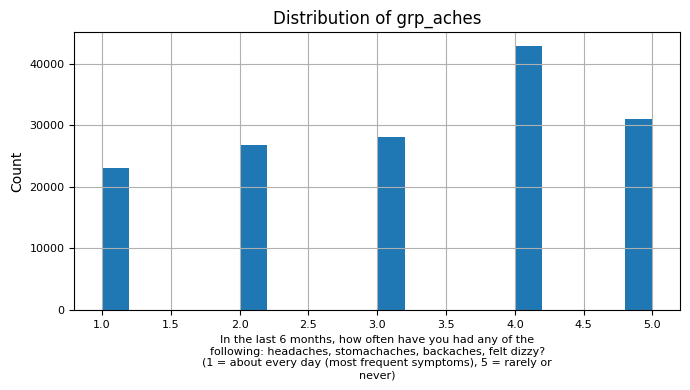

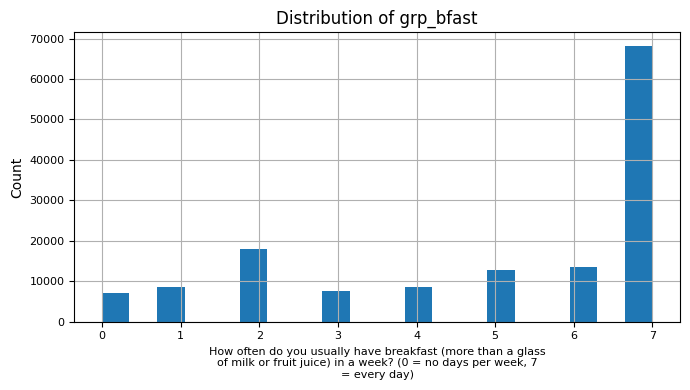

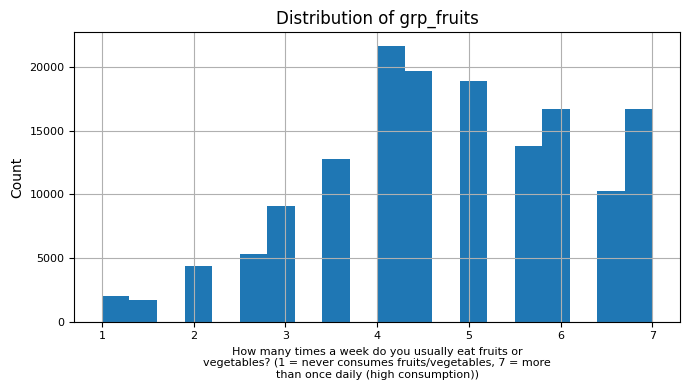

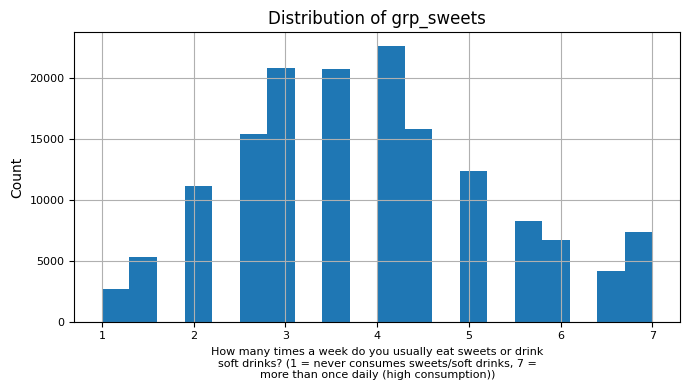

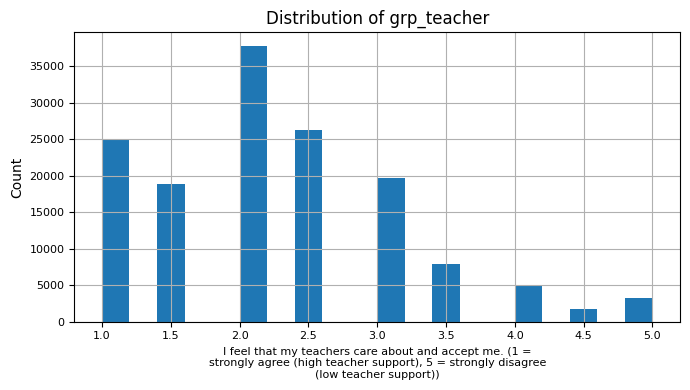

,feature,correlation,abs_correlation,n_used
9,grp_aches,-0.500189,0.500189,149491
10,sleepdificulty,-0.458658,0.458658,147935
8,health,0.351853,0.351853,150148
22,schoolpressure,0.315559,0.315559,148625
51,talkfather,0.289312,0.289312,142521
25,studaccept,0.281196,0.281196,141798
54,grp_fam_sup,-0.280108,0.280108,140755
52,talkmother,0.275206,0.275206,143900
21,likeschool,0.265700,0.265700,148797
26,grp_teacher,0.255979,0.255979,141088


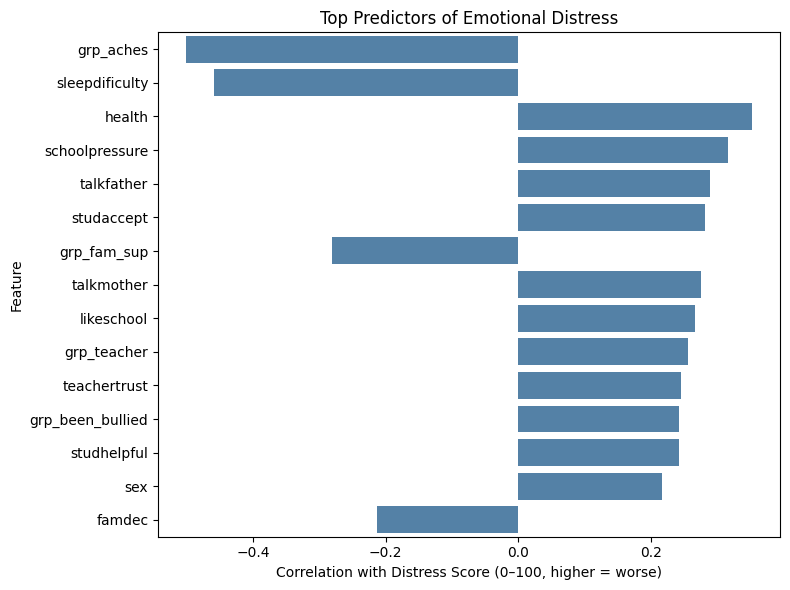

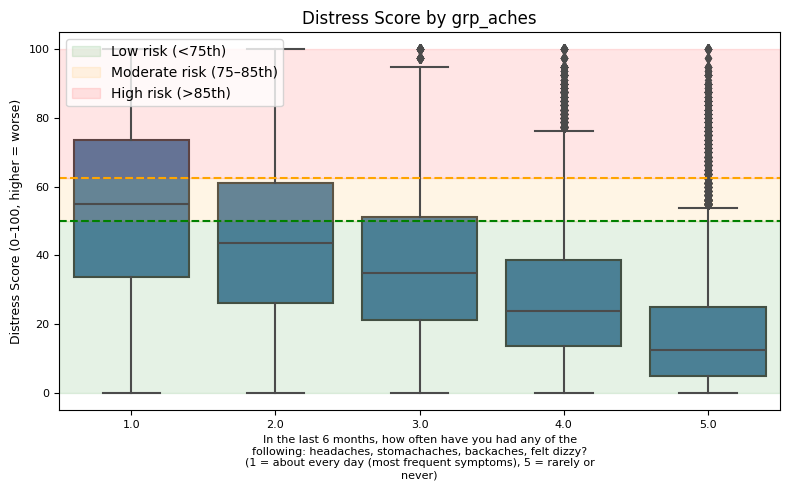

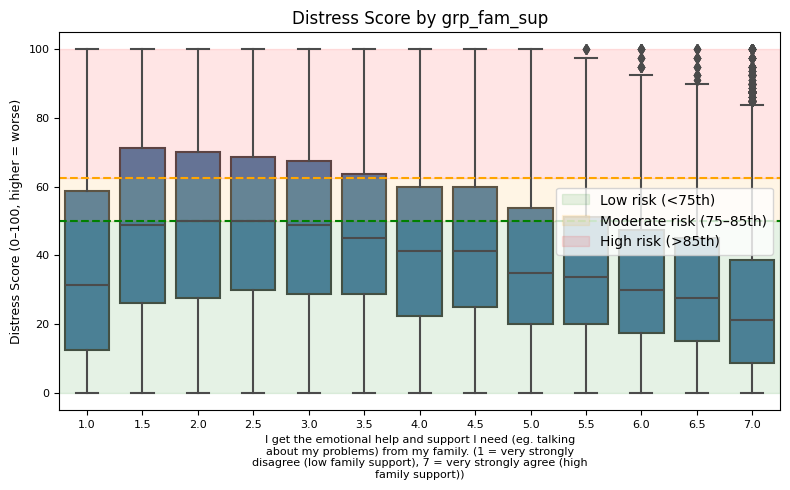

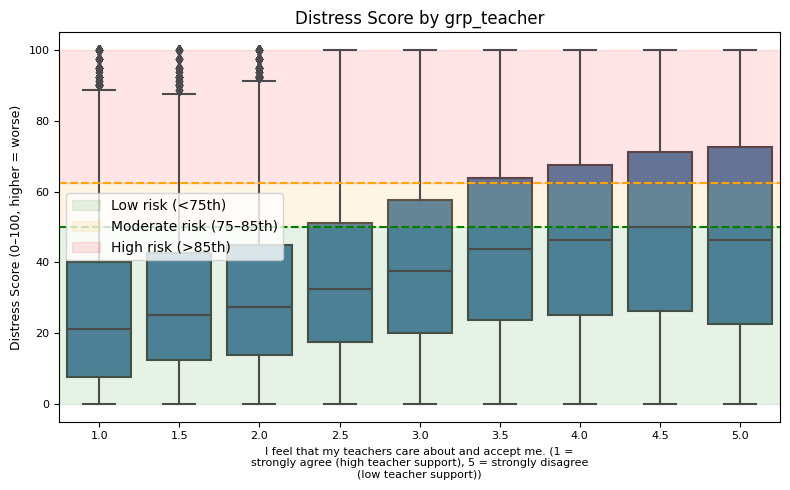

In [23]:
# ============================================================
# 6.7 EDA ON ENGINEERED FEATURES
# ============================================================

# ----------------------------
# 6.7.1 Identify engineered features
# ----------------------------
engineered_cols = feature_cols.copy()
grouped_cols = [c for c in engineered_cols if c.startswith("grp_")]

print("Total engineered features:", len(engineered_cols))
print("Grouped features:", len(grouped_cols))

# ----------------------------
# 6.7.2 Scale interpretation
# ----------------------------
scale_map = {

    "grp_aches": {
        "min": "1 = about every day (most frequent symptoms)",
        "max": "5 = rarely or never"
    },

    "grp_been_bullied": {
        "min": "1 = have not been bullied",
        "max": "5 = several times a week"
    },

    "grp_bullyothers": {
        "min": "1 = have not bullied others",
        "max": "5 = several times a week"
    },

    "grp_bfast": {
        "min": "0 = no days per week",
        "max": "7 = every day"
    },

    "grp_else_home": {
        "min": "1 = yes (lives somewhere other than parents/guardian)",
        "max": "2 = no"
    },

    "grp_fam_sup": {
        "min": "1 = very strongly disagree (low family support)",
        "max": "7 = very strongly agree (high family support)"
    },

    "grp_teacher": {
        "min": "1 = strongly agree (high teacher support)",
        "max": "5 = strongly disagree (low teacher support)"
    },

    "grp_fruits": {
        "min": "1 = never consumes fruits/vegetables",
        "max": "7 = more than once daily (high consumption)"
    },

    "grp_sweets": {
        "min": "1 = never consumes sweets/soft drinks",
        "max": "7 = more than once daily (high consumption)"
    }

}

# ----------------------------
# 6.7.3 Label mapping
# ----------------------------

# Grouped features -> use workbook-defined new_question
feature_label_map = dict(
    zip(feature_manifest["feature"], feature_manifest["new_question"])
)

def get_feature_label(col):
    """
    Return human-readable label:
    - grouped feature -> use new_question from feature_manifest
    - raw variable -> use original question stem()
    - fallback -> column name
    """
    if col in feature_label_map and feature_label_map[col]:
        return feature_label_map[col]
    
    try:
        return stem(col)
    except Exception:
        return col

# ----------------------------
# 6.7.4 Missingness analysis
# ----------------------------
missingness = df_model[engineered_cols].isna().mean().sort_values(ascending=False)

missingness_df = pd.DataFrame({
    "missing_pct": missingness * 100
})

display(missingness_df.head(15))  

# ----------------------------
# 6.7.5 Distribution plots
# ----------------------------
import matplotlib.pyplot as plt, textwrap

sample_grouped = grouped_cols[:5]

for col in sample_grouped:
    
    df_plot = df_model[[col]].dropna()
    
    # Build x-axis label using question/stem + scale interpretation
    if col in scale_map:
        xlabel_text = f"{get_feature_label(col)} ({scale_map[col]['min']}, {scale_map[col]['max']})"
    else:
        min_val = df_plot[col].min()
        max_val = df_plot[col].max()
        xlabel_text = f"{get_feature_label(col)} (min={min_val}, max={max_val})"
    
    wrapped_label = "\n".join(textwrap.wrap(xlabel_text, width=60))
    
    plt.figure(figsize=(7, 4))
    
    df_plot[col].hist(bins=20)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(wrapped_label, fontsize=8)
    plt.ylabel("Count")
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6.7.6 Correlation analysis
# ----------------------------
corr_rows = []

for col in engineered_cols:
    
    df_pair = df_model[[col, "distress_score_100"]].dropna()
    
    if len(df_pair) < 30:
        continue
    
    if df_pair[col].nunique() <= 1:
        continue
    
    corr_value = df_pair[col].corr(df_pair["distress_score_100"])
    
    corr_rows.append({
        "feature": col,
        "correlation": corr_value,
        "abs_correlation": abs(corr_value),
        "n_used": len(df_pair)
    })

corr_engineered = pd.DataFrame(corr_rows).sort_values("abs_correlation", ascending=False)

display(corr_engineered.head(15))

# ----------------------------
# 6.7.7 Top predictors
# ----------------------------
import seaborn as sns

top15 = corr_engineered.head(15).copy()

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top15,
    x="correlation",
    y="feature",
    color="steelblue"
)

plt.title("Top Predictors of Emotional Distress")
plt.xlabel("Correlation with Distress Score (0–100, higher = worse)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# ----------------------------
# 6.7.8 Boxplots (grouped features)
# ----------------------------
import textwrap

top_grouped = corr_engineered[corr_engineered["feature"].isin(grouped_cols)].head(3)["feature"]

for col in top_grouped:
    
    df_plot = df_model[[col, "distress_score_100"]].dropna()
    
    # Build x-axis label using grouped question + scale interpretation
    if col in scale_map:
        xlabel_text = f"{get_feature_label(col)} ({scale_map[col]['min']}, {scale_map[col]['max']})"
    else:
        xlabel_text = get_feature_label(col)
    
    # Wrap long labels to avoid cut-off
    wrapped_label = "\n".join(textwrap.wrap(xlabel_text, width=60))
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df_plot,
        x=col,
        y="distress_score_100",
        color="steelblue"
    )
    
    # Risk regions using same thresholds as earlier plots
    plt.axhspan(0, p75, color="green", alpha=0.1, label="Low risk (<75th)")
    plt.axhspan(p75, p85, color="orange", alpha=0.1, label="Moderate risk (75–85th)")
    plt.axhspan(p85, df_plot["distress_score_100"].max(), color="red", alpha=0.1, label="High risk (>85th)")
    
    # Threshold lines
    plt.axhline(p75, linestyle="--", color="green")
    plt.axhline(p85, linestyle="--", color="orange")
    
    # Title uses variable name, not question
    plt.title(f"Distress Score by {col}")
    plt.xlabel(wrapped_label, fontsize=8)
    plt.ylabel("Distress Score (0–100, higher = worse)", fontsize=9)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

# 7 Modelling Pipeline
Objective: 
Quantify the effective sample size available for modelling under different missing-data assumptions (target-only vs complete-case)
Preserve as many observations as possible by handling feature missingness through imputation rather than row deletion
Construct a clean modelling dataset (X, y) using all non-omitted engineered features and a valid distress score
Ensure feature completeness via imputation while maintaining the original distributional properties of the data
Prepare the dataset for initial model training and feature importance ranking in subsequent steps

- 7.1 Row count diagnostics preparation
- 7.2 Prepare inputs and target
- 7.3 Handle missing feature values
- 7.4 Train-test split
- 7.5 Train initial random forest classifier

## 7.1 Modelling dataset diagnostics

- 7.1.1 Define modelling columns
- 7.1.2 Count rows with target (max possibe)
- 7.1.3 Count strict complete-case rows
- 7.1.4 Summary table

In [24]:
# ----------------------------
# 7.1.1 Define modelling columns
# ----------------------------

# Combine feature columns with the target variable
# This defines the full set of columns required for modelling
model_cols = feature_cols + ["distress_score_100"]

# Print number of predictor variables (features only, excluding target)
print("Number of modelling features:", len(feature_cols))


# ----------------------------
# 7.1.2 Count rows with target
# ----------------------------

# Total number of rows in the dataset (before any filtering)
n_total_rows = len(df_model)

# Count how many rows have a non-missing target value
# These are the maximum usable rows for supervised learning
n_target_rows = df_model["distress_score_100"].notna().sum()

# Proportion of dataset that has a valid target
target_coverage = n_target_rows / n_total_rows

print("Total rows in df_model:", n_total_rows)
print("Rows with target (max possible):", n_target_rows)
print(f"Target coverage: {target_coverage:.2%}")


# ----------------------------
# 7.1.3 Count strict complete-case rows
# ----------------------------

# Keep only rows where ALL modelling columns (features + target) are non-missing
# This is a strict complete-case approach (no imputation used here)
df_complete = df_model[model_cols].dropna().copy()

# Number of rows that are fully complete across all variables
n_complete_rows = len(df_complete)

# Among rows with valid target, how many are fully usable without missing data
complete_coverage = n_complete_rows / n_target_rows if n_target_rows > 0 else np.nan

print("Rows with strict complete features:", n_complete_rows)
print(f"Complete-case coverage among rows with target: {complete_coverage:.2%}")


# ----------------------------
# 7.1.4 Summary table
# ----------------------------

# Create a summary table to clearly compare dataset sizes at each filtering stage
row_count_summary = pd.DataFrame({
    "dataset": [
        "All rows in df_model",                    # Raw dataset size
        "Rows with target (max possible)",         # Rows usable for supervised learning
        "Rows with strict complete features"       # Rows usable under complete-case assumption
    ],
    "n_rows": [
        n_total_rows,
        n_target_rows,
        n_complete_rows
    ]
})

# Display summary table (useful for reporting)
display(row_count_summary)

Number of modelling features: 56
Total rows in df_model: 156603
Rows with target (max possible): 150867
Target coverage: 96.34%
Rows with strict complete features: 65900
Complete-case coverage among rows with target: 43.68%


,dataset,n_rows
0,All rows in df_model,156603
1,Rows with target (max possible),150867
2,Rows with strict complete features,65900


## 7.2 Prepare features and classification target

- 7.2.1 Create classification target
- 7.2.2 Build working dataframe
- 7.2.3 Build strata for repeated OOS splitting
- 7.2.4 Build model inputs

In [83]:
# ----------------------------
# 7.2.1 Create classification target
# ----------------------------

# Define the ordered class labels for the distress risk categories
CLASS_LABELS = ["low", "medium", "high"]

# Define the percentile cutoffs used to split distress_score_100 into 3 classes
# Here:
# - below 75th percentile -> low
# - 75th to 85th percentile -> medium
# - above 85th percentile -> high
CLASS_PERCENTILES = (0.75, 0.85)

# Compute the numeric cutoff values using only rows with non-missing distress scores
cutoff_low, cutoff_high = np.quantile(
    df_model.loc[df_model["distress_score_100"].notna(), "distress_score_100"],
    CLASS_PERCENTILES
)

# Helper function to assign risk classes based on the two cutoff values
def assign_risk_classes_from_cutoffs(series, cutoff_low, cutoff_high):
    # Create bin edges spanning from negative infinity to positive infinity
    bins = [-np.inf, cutoff_low, cutoff_high, np.inf]
    
    # Use pd.cut to map each score into low / medium / high
    # right=False means intervals are left-closed, right-open:
    # [a, b) instead of (a, b]
    return pd.cut(
        series,
        bins=bins,
        labels=CLASS_LABELS,
        include_lowest=True,
        right=False,
    )

# Create the new categorical classification target from distress_score_100
df_model["risk_class"] = assign_risk_classes_from_cutoffs(
    df_model["distress_score_100"],
    cutoff_low,
    cutoff_high,
)

# Print the actual numerical thresholds used for class assignment
print(f"Using class cutoffs: low/medium={cutoff_low:.2f}, medium/high={cutoff_high:.2f}")

# Show the class distribution in the dataset, ordered as low / medium / high
print("\nRisk class distribution:")
print(df_model["risk_class"].value_counts().reindex(CLASS_LABELS))


# ----------------------------
# 7.2.2 Build working dataframe
# ----------------------------

# Build a modelling dataframe containing:
# - all predictor features
# - continuous target (distress_score_100)
# - classification target (risk_class)
# - age and sex for stratification / subgroup splitting
# dict.fromkeys is used to remove accidental duplicate column names while preserving order
working_cols = list(dict.fromkeys(feature_cols + ["distress_score_100", "risk_class", "age", "sex"]))

# Subset df_model to only the columns needed for modelling
working_df = df_model[working_cols].copy()

# Keep only rows with a valid risk_class
# Since risk_class comes from distress_score_100, this effectively removes rows with missing target
working_df = working_df[working_df["risk_class"].notna()].copy()

# Print final shape of the modelling dataframe
print("Working dataframe shape:", working_df.shape)


# ----------------------------
# 7.2.3 Build strata for repeated OOS splitting
# ----------------------------

# Create age bands to support more balanced train/test splitting
# These bins reflect the age range present in your HBSC sample
working_df["age_band"] = pd.cut(
    working_df["age"],
    bins=[13, 14, 15, 16, 16.5],
    include_lowest=True
).astype(str)

# Convert sex into string format so it can be combined with age_band
# Int64 allows missing-safe integer conversion before turning into string
working_df["sex_str"] = working_df["sex"].astype("Int64").astype(str)

# Create a combined stratification label using age band and sex
# Example: "(14.0, 15.0]__1"
working_df["strata"] = working_df["age_band"] + "__" + working_df["sex_str"]

# Minimum count required for a stratum to remain as its own group
# Small strata may cause unstable or invalid stratified train/test splits
MIN_STRATUM_COUNT = 30

# Count how many observations fall into each stratum
strata_counts = working_df["strata"].value_counts(dropna=False)

# Identify strata with too few observations
small_strata = strata_counts[strata_counts < MIN_STRATUM_COUNT].index

# Collapse rare strata into a single "other" bucket
# This improves robustness when doing repeated out-of-sample splitting
working_df.loc[working_df["strata"].isin(small_strata), "strata"] = "other"

# Print final stratum counts after collapsing small groups
print("\nStrata counts:")
print(working_df["strata"].value_counts(dropna=False))


# ----------------------------
# 7.2.4 Build model inputs
# ----------------------------

# Helper function to construct X and y inputs for modelling
def build_model_inputs(working_df, feature_names):
    # Predictor matrix
    X_data = working_df[feature_names].copy()
    
    # Continuous target (kept in case you want score-based analysis later)
    y_score = working_df["distress_score_100"].copy()
    
    # Classification target used for the main classification model
    y_class = working_df["risk_class"].copy()
    
    # Stratification labels used for train/test splitting
    strata_data = working_df["strata"].copy()

    # Force all feature columns to numeric
    # Non-numeric or invalid entries will be converted to NaN
    for col in X_data.columns:
        X_data[col] = pd.to_numeric(X_data[col], errors="coerce")

    # Identify columns with more than 95% missing values
    # These columns are too sparse to be useful for modelling
    drop_cols = X_data.columns[X_data.isnull().mean() > 0.95].tolist()

    # Drop overly sparse columns from X_data and update feature_names accordingly
    if drop_cols:
        X_data = X_data.drop(columns=drop_cols)
        feature_names = [c for c in feature_names if c not in drop_cols]

    # Return prepared modelling objects
    return X_data, y_score, y_class, strata_data, feature_names, drop_cols

# Build the final modelling inputs
X_all, y_score_all, y_class_all, strata_all, feature_cols_model, drop_cols = build_model_inputs(
    working_df,
    feature_cols
)

# Report columns dropped due to extreme missingness
if drop_cols:
    print(f"Dropping {len(drop_cols)} columns (>95% missing): {drop_cols}")

# Print final feature matrix shape before modelling begins
print("X_all shape before modelling:", X_all.shape)

Using class cutoffs: low/medium=50.00, medium/high=62.50

Risk class distribution:
risk_class
low       111481
medium     16469
high       22917
Name: count, dtype: int64
Working dataframe shape: (150867, 58)

Strata counts:
strata
(12.999, 14.0]__2    35913
(12.999, 14.0]__1    34569
(15.0, 16.0]__2      31952
(15.0, 16.0]__1      29484
(14.0, 15.0]__2       7186
(14.0, 15.0]__1       6917
(16.0, 16.5]__1       2487
(16.0, 16.5]__2       2359
Name: count, dtype: int64
X_all shape before modelling: (150867, 56)


## 7.3 Random forest model + light grid search

- 7.3.1 Import required modules
- 7.3.2 Define custom scorer
- 7.3.3 Define candidate RF pipeline
- 7.3.4 Define light local grid
- 7.3.5 Define cross-validation strategy
- 7.3.6 Run light grid search
- 7.3.7 Report best parameters

In [85]:
# ----------------------------
# 7.3.1 Import required modules
# ----------------------------
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

# ----------------------------
# 7.3.2 Define custom scorer
# ----------------------------
# Optimise specifically for recall of the "high" class.
# Since this is a multiclass problem, we define a custom function
# rather than using average="binary".
def high_class_recall(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=["high"],
        average=None,
        zero_division=0
    )[0]

high_recall_scorer = make_scorer(high_class_recall)

# ----------------------------
# 7.3.3 Define candidate RF pipeline
# ----------------------------
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=1,
        random_state=42,
    )),
])

# ----------------------------
# 7.3.4 Define light local grid
# ----------------------------
# This is a confirmatory local search around a previously identified
# strong RF configuration, rather than a full search from scratch.
rf_param_grid = {
    "model__n_estimators": [500, 800],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [3, 5],
    "model__max_features": ["sqrt", 0.5],
    "model__max_depth": [8, 10],
}

# ----------------------------
# 7.3.5 Define cross-validation strategy
# ----------------------------
cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

# ----------------------------
# 7.3.6 Run light grid search
# ----------------------------
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=high_recall_scorer,   # prioritise recall of the high-risk class
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=3
)

rf_grid.fit(X_all, y_class_all)

# Best tuned RF pipeline
tuned_rf_pipeline = rf_grid.best_estimator_

# ----------------------------
# 7.3.7 Report best parameters
# ----------------------------
print("Best RF parameters from light grid search:")
print(rf_grid.best_params_)
print(f"Best CV high-risk recall: {rf_grid.best_score_:.4f}")

Fitting 2 folds for each of 32 candidates, totalling 64 fits
Best RF parameters from light grid search:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__min_samples_split': 2, 'model__n_estimators': 800}
Best CV high-risk recall: 0.6621


## 7.4 Repeated OOS screening run

- 7.4.1 Helper functions
- 7.4.2 Preliminary RF screening run on all features
- 7.4.3 Plot full feature importance with 80% and 90% cutoffs

Run 1: test_accuracy=0.6817, test_macro_f1=0.5428, test_high_recall=0.6605
Run 2: test_accuracy=0.6780, test_macro_f1=0.5401, test_high_recall=0.6614
Run 3: test_accuracy=0.6735, test_macro_f1=0.5335, test_high_recall=0.6537
Run 4: test_accuracy=0.6797, test_macro_f1=0.5374, test_high_recall=0.6520
Run 5: test_accuracy=0.6784, test_macro_f1=0.5418, test_high_recall=0.6640

Screening feature importance summary:


,feature,mean_importance,std_importance
0,grp_aches,0.184528,0.001108
1,sleepdificulty,0.135230,0.000622
2,health,0.060469,0.001599
3,schoolpressure,0.052954,0.001021
4,grp_fam_sup,0.049365,0.001089
5,talkfather,0.037562,0.001175
6,emcsocmed8,0.033300,0.000684
7,talkmother,0.026786,0.000881
8,likeschool,0.026566,0.001017
9,grp_been_bullied,0.025833,0.000835



Selected 21 of 56 features to reach 80% cumulative importance.
Selected 30 of 56 features to reach 90% cumulative importance.


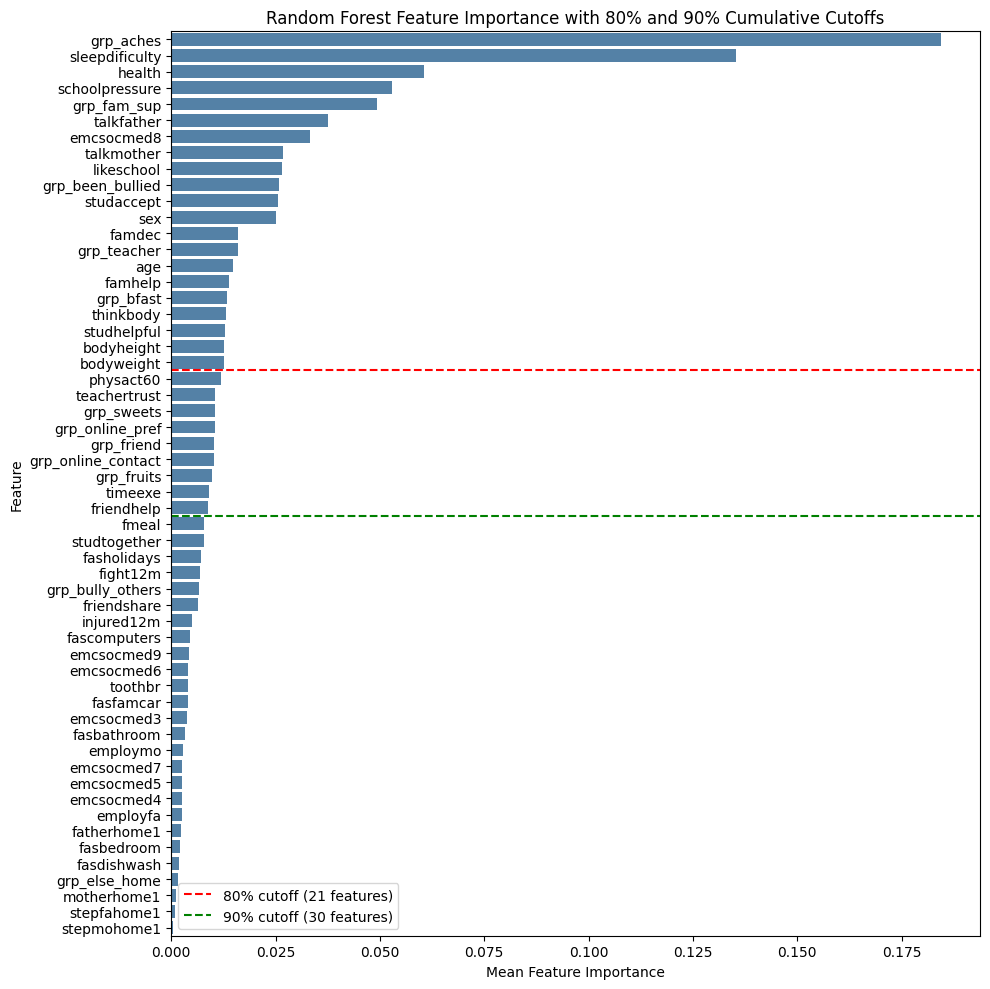

In [93]:
# ----------------------------
# 7.4.1 Helper functions
# ----------------------------
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    cohen_kappa_score,
    f1_score,
)

N_OOS_RUNS = 5
TEST_SIZE = 0.20
RANDOM_SEEDS = [11, 23, 37, 49, 61]
IMPORTANCE_COVERAGE = 0.80

def compute_multiclass_metrics(y_true, y_pred, labels=CLASS_LABELS):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, labels=labels, average="weighted")
    kappa = cohen_kappa_score(y_true, y_pred, labels=labels)
    quadratic_kappa = cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    metrics = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "cohen_kappa": kappa,
        "quadratic_kappa": quadratic_kappa,
    }

    for i, cls in enumerate(labels):
        metrics[f"{cls}_precision"] = precision[i]
        metrics[f"{cls}_recall"] = recall[i]
        metrics[f"{cls}_f1"] = f1[i]
        metrics[f"{cls}_support"] = support[i]

    return metrics, cm


def summarize_feature_importance(rf_importances):
    imp_df = pd.concat(rf_importances, ignore_index=True)
    return (
        imp_df.groupby("feature")
        .agg(
            mean_importance=("importance", "mean"),
            std_importance=("importance", "std"),
        )
        .sort_values("mean_importance", ascending=False)
        .reset_index()
    )


def select_top_features_by_importance(imp_summary, coverage):
    selection_df = imp_summary.copy()
    total_importance = selection_df["mean_importance"].sum()

    selection_df["importance_share"] = selection_df["mean_importance"] / total_importance
    selection_df["cumulative_importance"] = selection_df["importance_share"].cumsum()

    cutoff_idx = selection_df.index[
        selection_df["cumulative_importance"] >= coverage
    ][0]

    selection_df["selected_for_modelling"] = False
    selection_df.loc[:cutoff_idx, "selected_for_modelling"] = True

    selected_features = selection_df.loc[
        selection_df["selected_for_modelling"], "feature"
    ].tolist()

    return selection_df, selected_features


def build_split_strata(strata_data, y_class):
    combined = strata_data.astype(str) + "__" + y_class.astype(str)
    counts = combined.value_counts()
    return combined.where(combined.map(counts) >= 2, "other")


def run_repeated_oos_rf(model, X_data, y_class, strata_data, feature_names):
    all_oos_results = []
    rf_importances = []
    oos_prediction_rows = []
    confusion_store = {}

    for run_id, seed in enumerate(RANDOM_SEEDS[:N_OOS_RUNS], start=1):

        split_strata = build_split_strata(strata_data, y_class)

        X_train, X_test, y_train, y_test = train_test_split(
            X_data,
            y_class,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=split_strata,
        )

        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)

        y_pred_train = fitted_model.predict(X_train)
        y_pred_test = fitted_model.predict(X_test)
        y_pred_proba = fitted_model.predict_proba(X_test)

        train_metrics, _ = compute_multiclass_metrics(y_train, y_pred_train)
        test_metrics, cm = compute_multiclass_metrics(y_test, y_pred_test)

        row = {
            "run": run_id,
            "seed": seed,
            "train_accuracy": train_metrics["accuracy"],
            "test_accuracy": test_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "test_macro_f1": test_metrics["macro_f1"],
            "train_weighted_f1": train_metrics["weighted_f1"],
            "test_weighted_f1": test_metrics["weighted_f1"],
            "train_quadratic_kappa": train_metrics["quadratic_kappa"],
            "test_quadratic_kappa": test_metrics["quadratic_kappa"],
            "test_low_precision": test_metrics["low_precision"],
            "test_low_recall": test_metrics["low_recall"],
            "test_low_f1": test_metrics["low_f1"],
            "test_medium_precision": test_metrics["medium_precision"],
            "test_medium_recall": test_metrics["medium_recall"],
            "test_medium_f1": test_metrics["medium_f1"],
            "test_high_precision": test_metrics["high_precision"],
            "test_high_recall": test_metrics["high_recall"],
            "test_high_f1": test_metrics["high_f1"],
        }
        all_oos_results.append(row)
        confusion_store[run_id] = cm

        # Store test predictions and probabilities
        proba_df = pd.DataFrame(
            y_pred_proba,
            columns=[f"prob_{cls}" for cls in fitted_model.named_steps["model"].classes_],
            index=X_test.index
        )

        pred_df = pd.DataFrame({
            "run": run_id,
            "seed": seed,
            "row_index": y_test.index,
            "actual_class": y_test.astype(str).values,
            "predicted_class": pd.Series(y_pred_test, index=y_test.index).astype(str).values,
        }, index=X_test.index)

        oos_prediction_rows.append(
            pd.concat([pred_df, proba_df], axis=1).reset_index(drop=True)
        )

        # Store RF feature importance
        rf_importances.append(
            pd.DataFrame({
                "run": run_id,
                "feature": feature_names,
                "importance": fitted_model.named_steps["model"].feature_importances_,
            })
        )

        print(
            f"Run {run_id}: "
            f"test_accuracy={row['test_accuracy']:.4f}, "
            f"test_macro_f1={row['test_macro_f1']:.4f}, "
            f"test_high_recall={row['test_high_recall']:.4f}"
        )

    return (
        pd.DataFrame(all_oos_results),
        rf_importances,
        pd.concat(oos_prediction_rows, ignore_index=True),
        confusion_store,
    )
	
# ----------------------------
# 7.4.2 Preliminary RF screening run on all features
# ----------------------------
screening_oos_df, screening_rf_importances, screening_oos_predictions_df, screening_confusion_store = run_repeated_oos_rf(
    tuned_rf_pipeline,
    X_all,
    y_class_all,
    strata_all,
    feature_cols_model,
)

screening_imp_summary = summarize_feature_importance(screening_rf_importances)

# Define 80% and 90% cumulative-importance feature sets
selection_80_df, selected_feature_cols_80 = select_top_features_by_importance(
    screening_imp_summary,
    0.80,
)

selection_90_df, selected_feature_cols_90 = select_top_features_by_importance(
    screening_imp_summary,
    0.90,
)

print("\nScreening feature importance summary:")
display(screening_imp_summary)

print(
    f"\nSelected {len(selected_feature_cols_80)} of {len(feature_cols_model)} features "
    f"to reach 80% cumulative importance."
)
print(
    f"Selected {len(selected_feature_cols_90)} of {len(feature_cols_model)} features "
    f"to reach 90% cumulative importance."
)

# ----------------------------
# 7.4.3 Plot full feature importance with 80% and 90% cutoffs
# ----------------------------
plot_df = screening_imp_summary.copy()

# Add cumulative importance for plotting
total_importance = plot_df["mean_importance"].sum()
plot_df["importance_share"] = plot_df["mean_importance"] / total_importance
plot_df["cumulative_importance"] = plot_df["importance_share"].cumsum()

# Sort from highest to lowest importance
plot_df = plot_df.sort_values("mean_importance", ascending=False).reset_index(drop=True)

# Find cutoff positions
cutoff_80_idx = plot_df.index[plot_df["cumulative_importance"] >= 0.80][0]
cutoff_90_idx = plot_df.index[plot_df["cumulative_importance"] >= 0.90][0]

plt.figure(figsize=(10, 10))

ax = sns.barplot(
    data=plot_df,
    x="mean_importance",
    y="feature",
    color="steelblue"
)

# Draw horizontal cutoff lines
ax.axhline(cutoff_80_idx + 0.5, color="red", linestyle="--", linewidth=1.5,
           label=f"80% cutoff ({len(selected_feature_cols_80)} features)")
ax.axhline(cutoff_90_idx + 0.5, color="green", linestyle="--", linewidth=1.5,
           label=f"90% cutoff ({len(selected_feature_cols_90)} features)")

plt.title("Random Forest Feature Importance with 80% and 90% Cumulative Cutoffs")
plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

## 7.5 Final feature set + repeated OOS evaluation (use this for reporting)

- 7.5.1 Helper to summarize OOS performance
- 7.5.2 Repeated OOS validation on 80% feature set
- 7.5.3 Repeated OOS validation on 90% feature set
- 7.5.4 Compare OOS performance: 80% vs 90%
- 7.5.5 Final selected feature set for deployment
- 7.5.6 Pooled OOS classification metrics for 80% set
- 7.5.7 Pooled OOS classification metrics for 90% set
- 7.5.8 Pooled OOS confusion matrix for FINAL selected set (80%)
- 7.5.9 Pooled OOS classification report for FINAL selected set (80%)

Run 1: test_accuracy=0.6690, test_macro_f1=0.5395, test_high_recall=0.6406
Run 2: test_accuracy=0.6668, test_macro_f1=0.5368, test_high_recall=0.6369
Run 3: test_accuracy=0.6617, test_macro_f1=0.5321, test_high_recall=0.6321
Run 4: test_accuracy=0.6670, test_macro_f1=0.5338, test_high_recall=0.6343
Run 5: test_accuracy=0.6643, test_macro_f1=0.5374, test_high_recall=0.6474

Mean OOS metrics across runs for 80% set:


run                       3.0000
seed                     36.2000
train_accuracy            0.6998
test_accuracy             0.6658
train_macro_f1            0.5924
test_macro_f1             0.5359
train_weighted_f1         0.7322
test_weighted_f1          0.7043
train_quadratic_kappa     0.5620
test_quadratic_kappa      0.5291
test_low_precision        0.9146
test_low_recall           0.7134
test_low_f1               0.8016
test_medium_precision     0.1815
test_medium_recall        0.3814
test_medium_f1            0.2460
test_high_precision       0.4991
test_high_recall          0.6383
test_high_f1              0.5602
dtype: float64

Run 1: test_accuracy=0.6730, test_macro_f1=0.5397, test_high_recall=0.6489
Run 2: test_accuracy=0.6705, test_macro_f1=0.5377, test_high_recall=0.6446
Run 3: test_accuracy=0.6656, test_macro_f1=0.5310, test_high_recall=0.6406
Run 4: test_accuracy=0.6717, test_macro_f1=0.5362, test_high_recall=0.6424
Run 5: test_accuracy=0.6689, test_macro_f1=0.5384, test_high_recall=0.6537

Mean OOS metrics across runs for 90% set:


run                       3.0000
seed                     36.2000
train_accuracy            0.7104
test_accuracy             0.6699
train_macro_f1            0.6048
test_macro_f1             0.5366
train_weighted_f1         0.7400
test_weighted_f1          0.7066
train_quadratic_kappa     0.5681
test_quadratic_kappa      0.5291
test_low_precision        0.9134
test_low_recall           0.7194
test_low_f1               0.8049
test_medium_precision     0.1829
test_medium_recall        0.3681
test_medium_f1            0.2444
test_high_precision       0.4950
test_high_recall          0.6460
test_high_f1              0.5605
dtype: float64


OOS performance comparison: 80% vs 90% feature sets


,80% feature set,90% feature set,difference_80_minus_90
mean_test_accuracy,0.6658,0.6699,-0.0041
std_test_accuracy,0.0028,0.0029,-0.0001
mean_test_macro_f1,0.5359,0.5366,-0.0007
std_test_macro_f1,0.0030,0.0034,-0.0004
mean_test_weighted_f1,0.7043,0.7066,-0.0023
mean_test_quadratic_kappa,0.5291,0.5291,0.0000
mean_test_low_f1,0.8016,0.8049,-0.0033
mean_test_medium_f1,0.2460,0.2444,0.0016
mean_test_high_f1,0.5602,0.5605,-0.0003
mean_test_high_recall,0.6383,0.6460,-0.0077


Final selected feature count: 21
Final selected features:
 - grp_aches
 - sleepdificulty
 - health
 - schoolpressure
 - grp_fam_sup
 - talkfather
 - emcsocmed8
 - talkmother
 - likeschool
 - grp_been_bullied
 - studaccept
 - sex
 - famdec
 - grp_teacher
 - age
 - famhelp
 - grp_bfast
 - thinkbody
 - studhelpful
 - bodyheight
 - bodyweight
Full OOS classification metrics for 80% set:
  accuracy: 0.6658
  macro_f1: 0.5359
  weighted_f1: 0.7043
  cohen_kappa: 0.3567
  quadratic_kappa: 0.5291
  low_precision: 0.9146
  low_recall: 0.7134
  low_f1: 0.8016
  medium_precision: 0.1815
  medium_recall: 0.3814
  medium_f1: 0.2460
  high_precision: 0.4991
  high_recall: 0.6383
  high_f1: 0.5602
Full OOS classification metrics for 90% set:
  accuracy: 0.6699
  macro_f1: 0.5366
  weighted_f1: 0.7066
  cohen_kappa: 0.3601
  quadratic_kappa: 0.5291
  low_precision: 0.9134
  low_recall: 0.7194
  low_f1: 0.8049
  medium_precision: 0.1829
  medium_recall: 0.3681
  medium_f1: 0.2444
  high_precision: 0.49

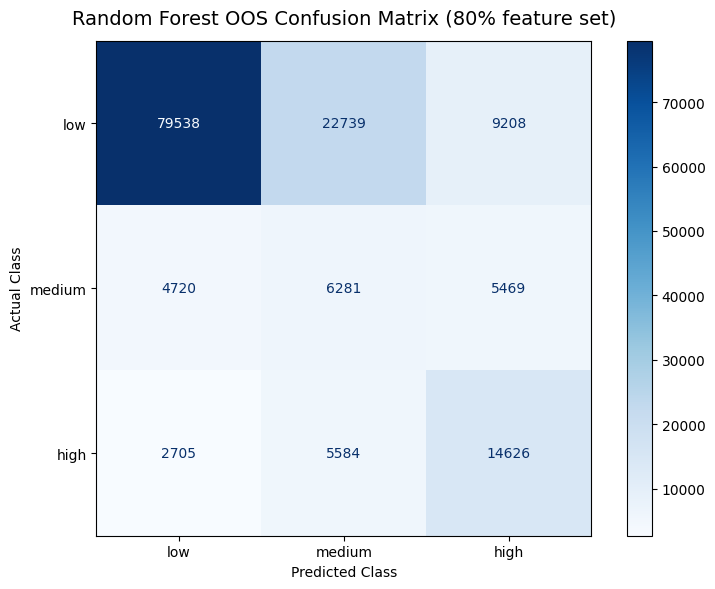


Full OOS classification report for final selected set (80%):
              precision    recall  f1-score   support

         low     0.9146    0.7134    0.8016    111485
      medium     0.1815    0.3814    0.2460     16470
        high     0.4991    0.6383    0.5602     22915

    accuracy                         0.6658    150870
   macro avg     0.5318    0.5777    0.5359    150870
weighted avg     0.7715    0.6658    0.7043    150870



In [94]:
# ----------------------------
# 7.5.1 Helper to summarize OOS performance
# ----------------------------
def summarize_oos_results(oos_df):
    return pd.Series({
        "mean_test_accuracy": oos_df["test_accuracy"].mean(),
        "std_test_accuracy": oos_df["test_accuracy"].std(),
        "mean_test_macro_f1": oos_df["test_macro_f1"].mean(),
        "std_test_macro_f1": oos_df["test_macro_f1"].std(),
        "mean_test_weighted_f1": oos_df["test_weighted_f1"].mean(),
        "mean_test_quadratic_kappa": oos_df["test_quadratic_kappa"].mean(),
        "mean_test_low_f1": oos_df["test_low_f1"].mean(),
        "mean_test_medium_f1": oos_df["test_medium_f1"].mean(),
        "mean_test_high_f1": oos_df["test_high_f1"].mean(),
        "mean_test_high_recall": oos_df["test_high_recall"].mean(),
        "mean_test_high_precision": oos_df["test_high_precision"].mean(),
    }).round(4)

# ----------------------------
# 7.5.2 Repeated OOS validation on 80% feature set
# ----------------------------
oos_80_df, rf_importances_80, oos_predictions_80_df, confusion_80_store = run_repeated_oos_rf(
    tuned_rf_pipeline,
    X_all[selected_feature_cols_80],
    y_class_all,
    strata_all,
    selected_feature_cols_80,
)

print("\nMean OOS metrics across runs for 80% set:")
display(oos_80_df.mean(numeric_only=True).round(4))

# ----------------------------
# 7.5.3 Repeated OOS validation on 90% feature set
# ----------------------------
oos_90_df, rf_importances_90, oos_predictions_90_df, confusion_90_store = run_repeated_oos_rf(
    tuned_rf_pipeline,
    X_all[selected_feature_cols_90],
    y_class_all,
    strata_all,
    selected_feature_cols_90,
)

print("\nMean OOS metrics across runs for 90% set:")
display(oos_90_df.mean(numeric_only=True).round(4))

# ----------------------------
# 7.5.4 Compare OOS performance: 80% vs 90%
# ----------------------------
comparison_df = pd.DataFrame({
    "80% feature set": summarize_oos_results(oos_80_df),
    "90% feature set": summarize_oos_results(oos_90_df),
})

comparison_df["difference_80_minus_90"] = (
    comparison_df["80% feature set"] - comparison_df["90% feature set"]
).round(4)

print("\nOOS performance comparison: 80% vs 90% feature sets")
display(comparison_df)

# ----------------------------
# 7.5.5 Final selected feature set for deployment
# ----------------------------
# Keep 80% as the final feature set used downstream in Sections 7.6 onward
selected_feature_cols = selected_feature_cols_80.copy()

print("Final selected feature count:", len(selected_feature_cols))
print("Final selected features:")
for feature_name in selected_feature_cols:
    print(" -", feature_name)

# ----------------------------
# 7.5.6 Pooled OOS classification metrics for 80% set
# ----------------------------
final_oos_metrics_80, final_oos_cm_80 = compute_multiclass_metrics(
    oos_predictions_80_df["actual_class"],
    oos_predictions_80_df["predicted_class"],
)

print("Full OOS classification metrics for 80% set:")
for k, v in final_oos_metrics_80.items():
    if "support" not in k:
        print(f"  {k}: {v:.4f}")

# ----------------------------
# 7.5.7 Pooled OOS classification metrics for 90% set
# ----------------------------
final_oos_metrics_90, final_oos_cm_90 = compute_multiclass_metrics(
    oos_predictions_90_df["actual_class"],
    oos_predictions_90_df["predicted_class"],
)

print("Full OOS classification metrics for 90% set:")
for k, v in final_oos_metrics_90.items():
    if "support" not in k:
        print(f"  {k}: {v:.4f}")

# ----------------------------
# 7.5.8 Pooled OOS confusion matrix for FINAL selected set (80%)
# ----------------------------
from sklearn.metrics import ConfusionMatrixDisplay

final_oos_cm = final_oos_cm_80
final_oos_predictions_df = oos_predictions_80_df
final_set_name = "80%"

final_oos_cm_df = pd.DataFrame(
    final_oos_cm,
    index=[f"actual_{c}" for c in CLASS_LABELS],
    columns=[f"pred_{c}" for c in CLASS_LABELS],
)

print(f"\nFull OOS confusion matrix for final selected set ({final_set_name}):")
print(final_oos_cm_df.to_string())

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_oos_cm,
    display_labels=CLASS_LABELS
)

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=True
)

ax.set_title(f"Random Forest OOS Confusion Matrix ({final_set_name} feature set)", fontsize=14, pad=12)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

# ----------------------------
# 7.5.9 Pooled OOS classification report for FINAL selected set (80%)
# ----------------------------
print(f"\nFull OOS classification report for final selected set ({final_set_name}):")
print(classification_report(
    final_oos_predictions_df["actual_class"],
    final_oos_predictions_df["predicted_class"],
    labels=CLASS_LABELS,
    zero_division=0,
    digits=4,
))

## 7.6 Full-sample deployment model outputs (use this for model deployment)

- 7.6.1 Recommendation logic for unfavourable responses
- 7.6.2 Fit deployment RF on full sample for deployment
- 7.6.3 Generate deployment outputs on full sample
- 7.6.4 Prepare deployment explainer components
- 7.6.5 Helper function for one-student deployment explanation
- 7.6.6 Example deployment call for one random student

In [88]:
# 7.6.1 Recommendation logic for unfavourable responses
# Features excluded from recommendation triggering
excluded_recommendation_features = {
    "age",
    "bodyheight",
    "bodyweight",
    "sex"
}

def is_unfavourable(feature_code, value):
    """
    Returns True if the feature value is considered unfavourable
    according to the provided rule set.
    """
    if pd.isna(value):
        return False

    if feature_code in excluded_recommendation_features:
        return False

    if feature_code == "grp_aches":
        return value < 4

    if feature_code == "sleepdificulty":
        return value < 4

    if feature_code == "health":
        return value > 2

    if feature_code == "schoolpressure":
        return value > 2

    if feature_code == "grp_fam_sup":
        return value < 4

    if feature_code == "talkfather":
        return value > 2

    if feature_code == "emcsocmed8":
        return value == 2

    if feature_code == "studaccept":
        return value > 3

    if feature_code == "grp_been_bullied":
        return value > 2

    if feature_code == "likeschool":
        return value > 3

    if feature_code == "talkmother":
        return value > 2

    if feature_code == "famdec":
        return value < 4

    if feature_code == "famhelp":
        return value < 4

    if feature_code == "studhelpful":
        return value > 3

    if feature_code == "grp_teacher":
        return value > 3

    if feature_code == "thinkbody":
        return value in [1, 5]

    if feature_code == "grp_bfast":
        return value < 4
    
    return False


def get_unfavourable_features(student_row, feature_cols):
    """
    Returns a list of features answered unfavourably for one student.
    """
    unfavourable = []

    for feat in feature_cols:
        value = student_row[feat]
        if is_unfavourable(feat, value):
            unfavourable.append({
                "feature_code": feat,
                "feature_label": get_feature_label(feat),
                "feature_value": float(value) if pd.notna(value) else None,
            })

    return unfavourable

# ----------------------------
# 7.6.2 Fit deployment RF on full sample for deployment
# ----------------------------
deployment_rf = clone(tuned_rf_pipeline)
deployment_rf.fit(X_all[selected_feature_cols], y_class_all)

print("Deployment Random Forest model fitted on full labelled sample.")

# ----------------------------
# 7.6.3 Generate deployment outputs on full sample
# ----------------------------
pred_class = deployment_rf.predict(X_all[selected_feature_cols])
proba = deployment_rf.predict_proba(X_all[selected_feature_cols])

proba_df = pd.DataFrame(
    proba,
    columns=[f"prob_{cls}" for cls in deployment_rf.named_steps["model"].classes_],
    index=X_all.index
)

deployment_output = pd.concat([
    working_df[["distress_score_100", "risk_class", "age", "sex"]].copy(),
    pd.DataFrame({
        "predicted_class": pred_class,
        "confidence": proba_df.max(axis=1),
        "p_high": proba_df["prob_high"],
    }, index=X_all.index),
    proba_df
], axis=1)

print("Deployment output sample:")
display(deployment_output.head(20))

# ----------------------------
# 7.6.4 Prepare deployment explainer components
# ----------------------------
import shap
import numpy as np

# Extract fitted components from pipeline
rf_model = deployment_rf.named_steps["model"]
rf_imputer = deployment_rf.named_steps["imputer"]

# Build SHAP explainer once
explainer = shap.TreeExplainer(rf_model)

# Safe class lookup
class_names = list(rf_model.classes_)
high_idx = class_names.index("high")

print("Deployment SHAP explainer ready.")
print("RF class order:", class_names)

# ----------------------------
# 7.6.5 Helper function for one-student deployment explanation
# ----------------------------
def explain_one_student(student_df, selected_feature_cols):
    """
    Generate deployment output for exactly one student.

    Returns:
        - predicted class
        - confidence
        - p_high
        - class probabilities
        - positive_shap_features: all features with positive SHAP for high-risk class
        - unfavourable_features: all features answered unfavourably based on rule logic
    """

    if len(student_df) != 1:
        raise ValueError("student_df must contain exactly one row.")

    # Keep only selected features in correct order
    X_one = student_df[selected_feature_cols].copy()

    # Apply fitted imputer
    X_one_imputed = pd.DataFrame(
        rf_imputer.transform(X_one),
        columns=selected_feature_cols,
        index=X_one.index
    )

    # Predict class and class probabilities
    pred_class = deployment_rf.predict(X_one)[0]
    pred_proba = deployment_rf.predict_proba(X_one)[0]

    prob_map = {
        f"prob_{cls}": float(pred_proba[i])
        for i, cls in enumerate(class_names)
    }

    confidence = float(np.max(pred_proba))
    p_high = float(pred_proba[high_idx])

    # Compute SHAP for this one student only
    shap_values = explainer.shap_values(X_one_imputed)

    # Always explain distress risk = high-risk class
    shap_high = shap_values[high_idx][0]

    # Collect ALL positive SHAP contributors toward high risk
    positive_idx = np.where(shap_high > 0)[0]
    ranked_idx = positive_idx[np.argsort(shap_high[positive_idx])[::-1]]

    positive_shap_features = []
    for idx in ranked_idx:
        feature_code = selected_feature_cols[idx]
        positive_shap_features.append({
            "feature_code": feature_code,
            "feature_label": get_feature_label(feature_code),
            "feature_value": float(X_one_imputed.iloc[0, idx]),
            "shap_value": float(shap_high[idx]),
        })

    # Recommendation logic based on raw answered feature values
    raw_student_row = X_one.iloc[0]
    unfavourable_features = get_unfavourable_features(raw_student_row, selected_feature_cols)

    result = {
        "predicted_class": pred_class,
        "confidence": confidence,
        "p_high": p_high,
        **prob_map,
        "positive_shap_features": positive_shap_features,
        "unfavourable_features": unfavourable_features,
    }

    return result
# ----------------------------
# 7.6.6 Example deployment call for one random student
# ----------------------------
random_idx = working_df.sample(n=1, random_state=None).index[0]
student_example = working_df.loc[[random_idx], selected_feature_cols]

student_explanation = explain_one_student(
    student_example,
    selected_feature_cols
)

student_explanation["true_class"] = str(working_df.loc[random_idx, "risk_class"])
student_explanation["true_distress_score_100"] = float(
    working_df.loc[random_idx, "distress_score_100"]
)
student_explanation["row_index"] = random_idx

print("Example one-student deployment explanation:")
display(student_explanation)

Deployment Random Forest model fitted on full labelled sample.
Deployment output sample:


,distress_score_100,risk_class,age,sex,predicted_class,confidence,p_high,prob_high,prob_low,prob_medium
43390,7.50,low,13.0,1,medium,0.400527,0.360710,0.360710,0.238763,0.400527
43391,6.25,low,13.0,1,low,0.388579,0.234041,0.234041,0.388579,0.377379
43392,12.50,low,13.0,1,low,0.875377,0.029799,0.029799,0.875377,0.094824
43393,23.75,low,13.0,1,low,0.753023,0.058568,0.058568,0.753023,0.188409
43394,62.50,high,13.0,1,medium,0.371213,0.301828,0.301828,0.326960,0.371213
43396,71.25,high,13.0,1,low,0.555496,0.162554,0.162554,0.555496,0.281950
43398,2.50,low,13.0,1,low,0.849908,0.032539,0.032539,0.849908,0.117552
43399,6.25,low,13.0,1,low,0.582619,0.126063,0.126063,0.582619,0.291318
43400,45.00,low,13.0,1,medium,0.419422,0.361212,0.361212,0.219366,0.419422
43401,5.00,low,13.0,1,low,0.778612,0.064701,0.064701,0.778612,0.156687


Deployment SHAP explainer ready.
RF class order: ['high', 'low', 'medium']
Example one-student deployment explanation:


{'predicted_class': 'low',
 'confidence': 0.5802590257589352,
 'p_high': 0.1280358496141409,
 'prob_high': 0.1280358496141409,
 'prob_low': 0.5802590257589352,
 'prob_medium': 0.2917051246269235,
 'positive_shap_features': [{'feature_code': 'sleepdificulty',
   'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.',
   'feature_value': 4.0,
   'shap_value': 0.13871465659043872}],
 'unfavourable_features': [{'feature_code': 'schoolpressure',
   'feature_label': 'How pressured do you feel by the schoolwork you have to do?',
   'feature_value': 3.0},
  {'feature_code': 'grp_bfast',
   'feature_label': 'How often do you usually have breakfast (more than a glass of milk or fruit juice) in a week?',
   'feature_value': 2.0}],
 'true_class': 'low',
 'true_distress_score_100': 2.5,
 'row_index': 242631}

# 8 Error analysis

- 8.1 Identify all misclassified cases
- 8.2 Missed high-risk cases
- 8.3 False high-risk predictions
- 8.4 Lowest-confidence cases
- 8.5 Compare feature patterns: correct high vs missed high
- 8.6 Example explanations for selected missed high-risk cases
- 8.7 Example explanations for false high-risk cases

In [89]:
# ----------------------------
# 8.1 Identify all misclassified cases
# ----------------------------
error_cases = deployment_output[
    deployment_output["predicted_class"] != deployment_output["risk_class"].astype(str)
].copy()

print("Total error cases:", len(error_cases))
print("Error rate:", round(len(error_cases) / len(deployment_output), 4))

display(error_cases.head(20))

# ----------------------------
# 8.2 Missed high-risk cases (false negatives)
# ----------------------------
missed_high = deployment_output[
    (deployment_output["risk_class"].astype(str) == "high") &
    (deployment_output["predicted_class"] != "high")
].copy()

print("Missed high-risk cases:", len(missed_high))

# Show the most concerning missed cases:
# high-risk students missed with high confidence
display(
    missed_high.sort_values(
        ["confidence", "p_high"],
        ascending=[False, True]
    ).head(20)
)

# ----------------------------
# 8.3 False high-risk predictions
# ----------------------------
false_high = deployment_output[
    (deployment_output["predicted_class"] == "high") &
    (deployment_output["risk_class"].astype(str) != "high")
].copy()

print("False high-risk cases:", len(false_high))

display(
    false_high.sort_values(
        ["p_high", "confidence"],
        ascending=[False, False]
    ).head(20)
)

# ----------------------------
# 8.4 Lowest-confidence cases
# ----------------------------
uncertain_cases = deployment_output.sort_values("confidence", ascending=True)

print("Lowest confidence cases:")
display(uncertain_cases.head(20))

# ----------------------------
# 8.5 Compare feature patterns: correct high vs missed high
# ----------------------------
correct_high = deployment_output[
    (deployment_output["risk_class"].astype(str) == "high") &
    (deployment_output["predicted_class"] == "high")
]

missed_high = deployment_output[
    (deployment_output["risk_class"].astype(str) == "high") &
    (deployment_output["predicted_class"] != "high")
]

feature_means_correct = working_df.loc[correct_high.index, selected_feature_cols].mean()
feature_means_missed = working_df.loc[missed_high.index, selected_feature_cols].mean()

comparison_df = pd.DataFrame({
    "correct_high": feature_means_correct,
    "missed_high": feature_means_missed,
    "difference": feature_means_correct - feature_means_missed
}).sort_values("difference", key=abs, ascending=False)

display(comparison_df.head(20))

# ----------------------------
# 8.6 Example explanations for selected missed high-risk cases
# ----------------------------
example_missed_idx = missed_high.sort_values(
    ["confidence", "p_high"],
    ascending=[False, True]
).head(5).index

missed_high_explanations = []
for idx in example_missed_idx:
    one_student_df = working_df.loc[[idx], selected_feature_cols]
    explanation = explain_one_student(one_student_df, selected_feature_cols)

    missed_high_explanations.append({
        "row_index": idx,
        "true_class": str(working_df.loc[idx, "risk_class"]),
        "true_distress_score_100": float(working_df.loc[idx, "distress_score_100"]),
        "predicted_class": explanation["predicted_class"],
        "confidence": explanation["confidence"],
        "p_high": explanation["p_high"],
        "positive_shap_features": explanation["positive_shap_features"],
    })

print("Example explanations for concerning missed high-risk cases:")
pd.set_option("display.max_colwidth", None)
display(pd.DataFrame(missed_high_explanations))

# ----------------------------
# 8.7 Example explanations for false high-risk cases
# ----------------------------
example_false_high_idx = false_high.sort_values(
    ["p_high", "confidence"],
    ascending=[False, False]
).head(5).index

false_high_explanations = []
for idx in example_false_high_idx:
    one_student_df = working_df.loc[[idx], selected_feature_cols]
    explanation = explain_one_student(one_student_df, selected_feature_cols)

    false_high_explanations.append({
        "row_index": idx,
        "true_class": str(working_df.loc[idx, "risk_class"]),
        "true_distress_score_100": float(working_df.loc[idx, "distress_score_100"]),
        "predicted_class": explanation["predicted_class"],
        "confidence": explanation["confidence"],
        "p_high": explanation["p_high"],
        "positive_shap_features": explanation["positive_shap_features"],
    })

print("Example explanations for false high-risk cases:")
pd.set_option("display.max_colwidth", None)
display(pd.DataFrame(false_high_explanations))

Total error cases: 46644
Error rate: 0.3092


,distress_score_100,risk_class,age,sex,predicted_class,confidence,p_high,prob_high,prob_low,prob_medium
43390,7.50,low,13.0,1,medium,0.400527,0.360710,0.360710,0.238763,0.400527
43394,62.50,high,13.0,1,medium,0.371213,0.301828,0.301828,0.326960,0.371213
43396,71.25,high,13.0,1,low,0.555496,0.162554,0.162554,0.555496,0.281950
43400,45.00,low,13.0,1,medium,0.419422,0.361212,0.361212,0.219366,0.419422
43404,23.75,low,13.0,1,medium,0.432625,0.336649,0.336649,0.230726,0.432625
43406,61.25,medium,13.0,1,low,0.515819,0.149508,0.149508,0.515819,0.334674
43409,52.50,medium,13.0,1,low,0.592342,0.119320,0.119320,0.592342,0.288339
43430,60.00,medium,13.0,1,low,0.839698,0.035936,0.035936,0.839698,0.124367
43431,63.75,high,13.0,1,medium,0.404822,0.357827,0.357827,0.237351,0.404822
43435,32.50,low,13.0,1,medium,0.401359,0.280480,0.280480,0.318161,0.401359


Missed high-risk cases: 7060


,distress_score_100,risk_class,age,sex,predicted_class,confidence,p_high,prob_high,prob_low,prob_medium
67813,68.75,high,13.666667,1,low,0.899531,0.025572,0.025572,0.899531,0.074897
232017,68.75,high,15.750000,2,low,0.886660,0.029853,0.029853,0.886660,0.083487
118787,68.75,high,16.083333,1,low,0.881716,0.027253,0.027253,0.881716,0.091031
107061,68.75,high,15.666667,1,low,0.876903,0.027753,0.027753,0.876903,0.095345
167718,62.50,high,13.083333,2,low,0.873341,0.039715,0.039715,0.873341,0.086945
242782,65.00,high,16.083333,2,low,0.873080,0.035391,0.035391,0.873080,0.091529
64328,87.50,high,13.583333,1,low,0.872490,0.031000,0.031000,0.872490,0.096510
73411,67.50,high,13.833333,1,low,0.872040,0.032663,0.032663,0.872040,0.095297
187347,77.50,high,13.666667,2,low,0.865539,0.036165,0.036165,0.865539,0.098296
79875,67.50,high,14.083333,1,low,0.865183,0.031585,0.031585,0.865183,0.103232


False high-risk cases: 12830


...

,correct_high,missed_high,difference
emcsocmed8,5.138235,3.282308,1.855926
sleepdificulty,2.092702,3.678472,-1.585770
grp_fam_sup,3.934829,5.492374,-1.557544
bodyweight,57.377596,55.996775,1.380820
famdec,4.459750,5.769529,-1.309779
famhelp,4.661352,5.928991,-1.267640
grp_aches,1.768149,2.818027,-1.049878
grp_bfast,3.828399,4.789424,-0.961025
talkmother,2.527381,1.822810,0.704571
talkfather,3.148556,2.451025,0.697530


Example explanations for concerning missed high-risk cases:


,row_index,true_class,true_distress_score_100,predicted_class,confidence,p_high,positive_shap_features
0,67813,high,68.75,low,0.899531,0.025572,"[{'feature_code': 'sleepdificulty', 'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.', 'feature_value': 5.0, 'shap_value': 0.1736664901539424}]"
1,232017,high,68.75,low,0.886660,0.029853,"[{'feature_code': 'sleepdificulty', 'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.', 'feature_value': 5.0, 'shap_value': 0.18224068304928806}]"
2,118787,high,68.75,low,0.881716,0.027253,"[{'feature_code': 'sleepdificulty', 'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.', 'feature_value': 5.0, 'shap_value': 0.17697226960749304}]"
3,107061,high,68.75,low,0.876903,0.027753,"[{'feature_code': 'sleepdificulty', 'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.', 'feature_value': 5.0, 'shap_value': 0.1464783341027568}]"
4,167718,high,62.50,low,0.873341,0.039715,"[{'feature_code': 'sleepdificulty', 'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.', 'feature_value': 4.0, 'shap_value': 0.17527657392841994}]"


Example explanations for false high-risk cases:


,row_index,true_class,true_distress_score_100,predicted_class,confidence,p_high,positive_shap_features
0,214780,medium,60.00,high,0.893797,0.893797,"[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 1.0, 'shap_value': 0.09037150307635436}]"
1,234238,low,45.00,high,0.862455,0.862455,"[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 2.0, 'shap_value': 0.04955456476682877}]"
2,235814,low,33.75,high,0.845210,0.845210,"[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 2.0, 'shap_value': 0.04945846685749541}]"
3,191036,medium,57.50,high,0.844405,0.844405,"[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 1.0, 'shap_value': 0.0795052316616297}]"
4,217013,medium,53.75,high,0.844045,0.844045,"[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 1.0, 'shap_value': 0.10815995658223923}]"


# 9 Playground

- 9.1 Build a default playground template
- 9.2 Helper: identify unfavourable responses
- 9.3 Helper: explain one student using HIGH-risk SHAP
- 9.4 Playground input: manually edit feature values here
- 9.5 Run playground simulation
- 9.6 Flatten output for frontend-style display
- 9.7 Flattened views for easier inspection

In [90]:
# ----------------------------
# 9.1 Build a default playground template
# ----------------------------
# Use medians from the modelling data as safe defaults
playground_defaults = (
    X_all[selected_feature_cols]
    .median(numeric_only=True)
    .reindex(selected_feature_cols)
)

playground_template = pd.DataFrame([playground_defaults], columns=selected_feature_cols)

print("Playground template created.")
display(playground_template)

# ----------------------------
# 9.2 Helper: identify unfavourable responses
# ----------------------------
excluded_recommendation_features = {
    "age",
    "bodyheight",
    "bodyweight",
    "sex"
}

def is_unfavourable(feature_code, value):
    """
    Returns True if the feature value is considered unfavourable
    according to the provided rule set.
    """
    if pd.isna(value):
        return False

    if feature_code in excluded_recommendation_features:
        return False

    if feature_code == "grp_aches":
        return value < 4

    if feature_code == "sleepdificulty":
        return value < 4

    if feature_code == "health":
        return value > 2

    if feature_code == "schoolpressure":
        return value > 2

    if feature_code == "grp_fam_sup":
        return value < 4

    if feature_code == "talkfather":
        return value > 2

    if feature_code == "emcsocmed8":
        return value == 2

    if feature_code == "studaccept":
        return value > 3

    if feature_code == "grp_been_bullied":
        return value > 2

    if feature_code == "likeschool":
        return value > 3

    if feature_code == "talkmother":
        return value > 2

    if feature_code == "famdec":
        return value < 4

    if feature_code == "famhelp":
        return value < 4

    if feature_code == "studhelpful":
        return value > 3

    if feature_code == "grp_teacher":
        return value > 3

    if feature_code == "thinkbody":
        return value in [1, 5]

    if feature_code == "grp_bfast":
        return value < 4
    
    return False



def get_unfavourable_features(student_row, feature_cols):
    """
    Return all features answered unfavourably for one student/playground row.
    """
    unfavourable = []

    for feat in feature_cols:
        value = student_row[feat]
        if is_unfavourable(feat, value):
            unfavourable.append({
                "feature_code": feat,
                "feature_label": get_feature_label(feat),
                "feature_value": float(value) if pd.notna(value) else None,
            })

    return unfavourable

# ----------------------------
# 9.3 Helper: explain one student using HIGH-risk SHAP
# ----------------------------
import numpy as np
import pandas as pd

rf_model = deployment_rf.named_steps["model"]
rf_imputer = deployment_rf.named_steps["imputer"]

def explain_one_student_risk(student_df, selected_feature_cols):
    """
    Simulate real deployment for exactly one student/playground row.

    Returns:
        - predicted class
        - confidence
        - p_high
        - all class probabilities
        - positive_shap_features: all features with positive SHAP for HIGH risk
        - unfavourable_features: all features answered unfavourably
    """
    if len(student_df) != 1:
        raise ValueError("student_df must contain exactly one row.")

    # Keep only selected features in the correct order
    X_one = student_df[selected_feature_cols].copy()

    # Impute using fitted deployment pipeline
    X_one_imputed = pd.DataFrame(
        rf_imputer.transform(X_one),
        columns=selected_feature_cols,
        index=X_one.index
    )

    # Predict class and probabilities
    pred_class = deployment_rf.predict(X_one)[0]
    pred_proba = deployment_rf.predict_proba(X_one)[0]

    prob_map = {
        f"prob_{cls}": float(pred_proba[i])
        for i, cls in enumerate(class_names)
    }

    confidence = float(np.max(pred_proba))
    high_idx = class_names.index("high")
    p_high = float(pred_proba[high_idx])

    # SHAP for this one row
    shap_values = explainer.shap_values(X_one_imputed)

    # Always explain HIGH-risk direction
    shap_high = shap_values[high_idx][0]

    # Collect all features with positive SHAP toward HIGH risk
    positive_idx = np.where(shap_high > 0)[0]
    ranked_idx = positive_idx[np.argsort(shap_high[positive_idx])[::-1]]

    positive_shap_features = []
    for idx in ranked_idx:
        feature_code = selected_feature_cols[idx]
        positive_shap_features.append({
            "feature_code": feature_code,
            "feature_label": get_feature_label(feature_code),
            "feature_value": float(X_one_imputed.iloc[0, idx]),
            "shap_value": float(shap_high[idx]),
        })

    # Recommendation logic based on raw answers
    raw_student_row = X_one.iloc[0]
    unfavourable_features = get_unfavourable_features(raw_student_row, selected_feature_cols)

    result = {
        "predicted_class": pred_class,
        "confidence": confidence,
        "p_high": p_high,
        **prob_map,
        "positive_shap_features": positive_shap_features,
        "unfavourable_features": unfavourable_features,
    }

    return result

# ----------------------------
# 9.4 Playground input: manually edit feature values here
# ----------------------------
playground_input = playground_template.copy()

# Example manual overrides
playground_input.loc[0, "grp_aches"] = 1          # 1=about every day, 5=rarely or never
playground_input.loc[0, "sleepdificulty"] = 2     # 1=about every day, 5=rarely or never
playground_input.loc[0, "health"] = 4             # 1=excellent, 4=poor
playground_input.loc[0, "schoolpressure"] = 4     # 1=not at all, 4 =a lot
playground_input.loc[0, "grp_fam_sup"] = 1        # 1=very strongly disagree, 7=very strongly agree
playground_input.loc[0, "talkfather"] = 5         # 1=very easy, 5=dont have or see
playground_input.loc[0, "emcsocmed8"] = 2         # 1=no, 2=yes
playground_input.loc[0, "talkmother"] = 5         # 1=very easy, 5=dont have or see
playground_input.loc[0, "likeschool"] = 4         # 1=like a lot, 4 = not at all
playground_input.loc[0, "grp_been_bullied"] = 1   # 1=havent, 5=several times a week
playground_input.loc[0, "studaccept"] = 1         # 1=strongly agree, 5=strongly disagree
playground_input.loc[0, "sex"] = 1                # 1=male, 2=female
playground_input.loc[0, "famdec"] = 7             # 1=very strongly disagree, 7=very strongly agree
playground_input.loc[0, "grp_teacher"] = 1        # 1=strongly agree, 5=strongly disagree
playground_input.loc[0, "age"] = 16               # numeric
playground_input.loc[0, "famhelp"] = 7            # 1=very strongly disagree, 7=very strongly agree
playground_input.loc[0, "grp_bfast"] = 7          # 0=never, 7=seven days
playground_input.loc[0, "thinkbody"] = 3          # 1=much too thin, 5=much too fat
playground_input.loc[0, "studhelpful"] = 1        # 1=strongly agree, 5=strongly disagree
playground_input.loc[0, "bodyheight"] = 160       # numeric
playground_input.loc[0, "bodyweight"] = 80        # numeric

print("Playground input row:")
display(playground_input)

# ----------------------------
# 9.5 Run playground simulation
# ----------------------------
playground_result = explain_one_student_risk(
    playground_input,
    selected_feature_cols
)

print("Playground prediction result:")
display(playground_result)

# ----------------------------
# 9.6 Flatten output for frontend-style display
# ----------------------------
positive_feats = playground_result["positive_shap_features"]
unfavourable_feats = playground_result["unfavourable_features"]

playground_frontend_output = pd.DataFrame([{
    "predicted_class": playground_result["predicted_class"],
    "confidence": playground_result["confidence"],
    "p_high": playground_result["p_high"],
    "prob_low": playground_result.get("prob_low"),
    "prob_medium": playground_result.get("prob_medium"),
    "prob_high": playground_result.get("prob_high"),
    "positive_shap_features": positive_feats,
    "unfavourable_features": unfavourable_feats,
}])

pd.set_option("display.max_colwidth", None)

print("Frontend-style playground output:")
display(playground_frontend_output)

# ----------------------------
# 9.7 Flattened views for easier inspection
# ----------------------------
positive_shap_df = pd.DataFrame(positive_feats)
unfavourable_df = pd.DataFrame(unfavourable_feats)

print("Positive SHAP features toward HIGH risk:")
display(positive_shap_df)

print("Unfavourable features for recommendation logic:")
display(unfavourable_df)

Playground template created.


,grp_aches,sleepdificulty,health,schoolpressure,grp_fam_sup,talkfather,emcsocmed8,talkmother,likeschool,grp_been_bullied,studaccept,sex,famdec,grp_teacher,age,famhelp,grp_bfast,thinkbody,studhelpful,bodyheight,bodyweight
0,3.0,4.0,2.0,2.0,6.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,7.0,2.0,14.333333,7.0,6.0,3.0,2.0,166.0,55.0


Playground input row:


,grp_aches,sleepdificulty,health,schoolpressure,grp_fam_sup,talkfather,emcsocmed8,talkmother,likeschool,grp_been_bullied,studaccept,sex,famdec,grp_teacher,age,famhelp,grp_bfast,thinkbody,studhelpful,bodyheight,bodyweight
0,1.0,2.0,4.0,4.0,1.0,5.0,2.0,5.0,4.0,1.0,1.0,1.0,7.0,1.0,16.0,7.0,7.0,3.0,1.0,160.0,80.0


Playground prediction result:


...

,predicted_class,confidence,p_high,prob_low,prob_medium,prob_high,positive_shap_features,unfavourable_features
0,high,0.723521,0.723521,0.054534,0.221945,0.723521,"[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 1.0, 'shap_value': 0.09530462875572655}]","[{'feature_code': 'grp_aches', 'feature_label': 'In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?', 'feature_value': 1.0}, {'feature_code': 'sleepdificulty', 'feature_label': 'In the last 6 months: how often have you had the following? Please tick one box for each line.', 'feature_value': 2.0}, {'feature_code': 'health', 'feature_label': 'Would you say your health is…?', 'feature_value': 4.0}, {'feature_code': 'schoolpressure', 'feature_label': 'How pressured do you feel by the schoolwork you have to do?', 'feature_value': 4.0}, {'feature_code': 'grp_fam_sup', 'feature_label': 'I get the emotional help and support I need (eg. talking about my problems) from my family.', 'feature_value': 1.0}, {'feature_code': 'talkfather', 'feature_label': 'How easy is it for you to talk to the following persons about things that really bother you? Please tick one box for each line.', 'feature_value': 5.0}, {'feature_code': 'emcsocmed8', 'feature_label': 'In the last year, how often have these experiences happened because of social media use?', 'feature_value': 2.0}, {'feature_code': 'talkmother', 'feature_label': 'How easy is it for you to talk to the following persons about things that really bother you? Please tick one box for each line.', 'feature_value': 5.0}, {'feature_code': 'likeschool', 'feature_label': 'How do you feel about school at present?', 'feature_value': 4.0}]"


Positive SHAP features toward HIGH risk:


,feature_code,feature_label,feature_value,shap_value
0,grp_aches,"In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?",1.0,0.095305


Unfavourable features for recommendation logic:


,feature_code,feature_label,feature_value
0,grp_aches,"In the last 6 months, how often have you had any of the following: headaches, stomachaches, backaches, felt dizzy?",1.0
1,sleepdificulty,In the last 6 months: how often have you had the following? Please tick one box for each line.,2.0
2,health,Would you say your health is…?,4.0
3,schoolpressure,How pressured do you feel by the schoolwork you have to do?,4.0
4,grp_fam_sup,I get the emotional help and support I need (eg. talking about my problems) from my family.,1.0
5,talkfather,How easy is it for you to talk to the following persons about things that really bother you? Please tick one box for each line.,5.0
6,emcsocmed8,"In the last year, how often have these experiences happened because of social media use?",2.0
7,talkmother,How easy is it for you to talk to the following persons about things that really bother you? Please tick one box for each line.,5.0
8,likeschool,How do you feel about school at present?,4.0
